# Code 3. Naming divergence across six labelling streams (v1.0; N = 47 field particles)

Companion code for the naming-divergence analysis. Upstream inputs are produced by
Code 1 (Raman, `v1.0`) and Code 2 (FT-IR, `v1.0 / p1`); this notebook adds the
Open Specy and siMPLe streams and compares all streams on the same particles.

## Labelling streams

Tables and figures use the short label in the first column. The full description of each
library is written to `SI_stream_dictionary.csv` by F2.

| Label | Modality | Library / method | CSV column |
|---|---|---|---|
| **1. Raman ref** | Raman | in-house rule + evidence floor *(reference axis)* | `raman_gt` |
| **2. SLoPP** | Raman | SLoPP **and SLoPP-E** libraries, Code 1 preprocessing | `B_label` |
| **3. spec_class** | FT-IR | in-house rule, functional-group level classes | `spec_class` |
| **4. omnic_name** | FT-IR | OMNIC commercial libraries (Thermo Fisher) | `omnic_name` |
| **5. OS_cor** | FT-IR | Open Specy `derivative` library, `match_spec` | `openspecy_name` |
| **6. OS_ml** | FT-IR | Open Specy `model_derivative`, `ai_classify` | `ml_name` |
| **7. siMPLe** | FT-IR | siMPLe ATR single-spectra reference library | `simple_name` |

Label **2. SLoPP** covers both the SLoPP and SLoPP-E libraries; a note to this effect is
suitable for the table footnotes and the methods text.

**Streams 2 and 5 are different things.** Stream 2 is correlation matching against the
SLoPP / SLoPP-E *libraries* using this project's Raman preprocessing; the Open Specy
*software* was not run. Stream 5 is Open Specy correlation matching on FT-IR spectra.

**Stream 7 does not run the siMPLe software.** siMPLe is built for FPA imaging maps and
cannot take single-point ATR spectra. What is used here is the separately distributed
*Single spectra IR* ATR reference library, matched with the same routine as stream 5.
The accurate description is *correlation matching against the siMPLe ATR reference library*.

## Two analysis layers, two denominators

| Layer | N | Reference needed | Question |
|---|---|---|---|
| Reference-free | **47** | no | do the tools agree with each other? |
| Reference-anchored | **33** | yes | how far does each tool sit from the Raman reference? |

The evidence floor withheld a class for 14 of the 47 particles. Those particles still carry
six FT-IR/Raman names, so they are used in the reference-free layer. **Do not mix the two
denominators.**

## What this notebook does not do

1. It does not decide which stream is *right*. The reference is a reproducible rule, not a
   verified ground truth; what is measured is **divergence**, not accuracy.
2. It does not translate names between schemes. A mapping table is an author assumption and
   it shrinks the very quantity being measured. Scoring uses **group structure** only.
3. It does not filter particles by support level. All particles are analysed and reported
   stratified.
4. It never overwrites a verbatim name column. Derived columns are always new.

## Layout

- **Parts A–C** build the data: run the two Open Specy streams, ingest the siMPLe library,
  and assemble the master table.
- **Part D: main results.** The quantities intended for the article body.
- **Part E: supplementary.** Confirmatory tests; safe to skip. Results in Part D do not
  depend on Part E having been run.
- **Part F** writes the figures, reporting values and output files.
---
© 2026 Youjin Kim. Licensed under CC BY-NC 4.0.
Part of the archive "field_MPs_codes"; for the licence, citation and DOI see
`LICENSE` and `CITATION.cff` in the repository root (github.com/yjkcode0828/field_MPs_codes).


In [ ]:
# === Setup 0-0: mount Google Drive and stage inputs ==========================
from google.colab import drive; drive.mount('/content/drive')
import os, shutil, glob

PROJECT = '/content/drive/MyDrive/mp_project'

STAGE_IN = [
    ('code2_out',        'Code 2 output: catalogue + parameter snapshot   REQUIRED'),
    ('spectra',          'raw FT-IR spectra (CSV)                         REQUIRED'),
    ('simple_lib',       'siMPLe ATR reference library (txt)              stream 7'),
    ('raman_manual_out', 'Code 1 output, for reference only               optional'),
]
for _name, _what in STAGE_IN:
    _src, _dst = os.path.join(PROJECT, _name), f'/content/{_name}'
    os.makedirs(_dst, exist_ok=True)
    _n = sum(bool(shutil.copy(p, _dst))
             for p in glob.glob(os.path.join(_src, '*')) if os.path.isfile(p))
    print(f'  /content/{_name:<18}{_n:>5} files   {_what}')

OUT_DIR = '/content/code3_out'; os.makedirs(OUT_DIR, exist_ok=True)

print('-' * 78)
for _f, _need in [('/content/code2_out/code3_input_catalogue_v01.csv', 'REQUIRED  input contract'),
                  ('/content/code2_out/params_snapshot_p1.json',       'REQUIRED  frozen vocabulary')]:
    print(f"  {'ok ' if os.path.exists(_f) else '!! '}{os.path.basename(_f):<38}{_need}")
_ftir = glob.glob('/content/spectra/*.CSV') + glob.glob('/content/spectra/*.csv')
print(f"  {'ok ' if _ftir else '!! '}{'spectra/*.CSV':<38}{len(_ftir)} files")
_slib = glob.glob('/content/simple_lib/*.txt') + glob.glob('/content/simple_lib/*.TXT')
print(f"  {'ok ' if _slib else '-- '}{'simple_lib/*.txt':<38}"
      f"{len(_slib)} files (absent -> five streams instead of six)")

print('\n  Note: code2_out/ and raman_manual_out/ are read-only upstream products.')


Mounted at /content/drive
  /content/code2_out            23 files   Code 2 output: catalogue + parameter snapshot   REQUIRED
  /content/spectra             230 files   raw FT-IR spectra (CSV)                         REQUIRED
  /content/simple_lib            1 files   siMPLe ATR reference library (txt)              stream 7
  /content/raman_manual_out     71 files   Code 1 output, for reference only               optional
------------------------------------------------------------------------------
  ok code3_input_catalogue_v01.csv         REQUIRED  input contract
  ok params_snapshot_p1.json               REQUIRED  frozen vocabulary
  ok spectra/*.CSV                         230 files
  ok simple_lib/*.txt                      1 files (absent -> five streams instead of six)

  Note: code2_out/ and raman_manual_out/ are read-only upstream products.


In [ ]:
# === Setup: configuration and stream registry ================================
%load_ext rpy2.ipython
import os, re, json, glob
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from itertools import combinations
from scipy import stats
pd.set_option('display.width', 250); pd.set_option('display.max_rows', 300)
pd.set_option('display.max_colwidth', 34)

CODE3_VERSION = "v1.0"
UPSTREAM = dict(code1="v1.0", code2="v1.0 / p1")

CAT_PATH      = '/content/code2_out/code3_input_catalogue_v01.csv'
PARAM_PATH    = '/content/code2_out/params_snapshot_p1.json'
FTIR_DIR      = '/content/spectra'
SIMPLE_DIR    = '/content/simple_lib'
TARGET_WN_CSV = os.path.join(OUT_DIR, 'target_wn.csv')            # A2 (R)  -> A5a (Python)
OS_LONG       = os.path.join(OUT_DIR, 'openspecy_results_long.csv')
OS_ML         = os.path.join(OUT_DIR, 'openspecy_ml_per_particle.csv')
OS_VOCAB      = os.path.join(OUT_DIR, 'openspecy_vocab.csv')      # A3 (R)  -> C1 (Python)
LIB_CSV       = os.path.join(OUT_DIR, 'simple_lib_matrix.csv')    # A5a     -> A5b (R)
LIB_INDEX     = os.path.join(OUT_DIR, 'simple_lib_index.csv')
SIMPLE_OUT    = os.path.join(OUT_DIR, 'simple_per_particle.csv')  # A4b (R) -> B1 (Python)

JOIN_KEY = 'file'        # spectra and library outputs are both one row per spectrum file
REF_COL  = 'raman_gt'    # stream 1, the reference axis; never scored against itself
GT_EXCLUDE_FROM_ACCURACY = {'unresolved', 'coating_alkyd'}   # same set as Code 2 section 4.1
HELDOUT_BATCH = {'07.11': 'heldout_1', '07.12': 'heldout_1', '07.25': 'heldout_2'}

# Match-score thresholds are RECORDED, not applied. A below-threshold hit is still an
# output of the tool; excluding it would give each stream a different denominator.
OS_THRESHOLD, ML_THRESHOLD = 0.70, 0.30

# Short table labels; the full description of each library is in `library` and is
# reproduced by the stream dictionary written in F2.
STREAMS = [
    dict(no=2, key='B_label',        name='SLoPP',       modality='Raman',
         score='B_r',                 n_returnable=7,
         library='SLoPP and SLoPP-E Raman libraries, matched with the Code 1 '
                 'preprocessing; the Open Specy software was not used'),
    dict(no=3, key='spec_class',     name='spec_class',  modality='FT-IR',
         score=None,                  n_returnable=11,
         library='in-house rule, functional-group level classes'),
    dict(no=4, key='omnic_name',     name='omnic_name',  modality='FT-IR',
         score='hqi',                 n_returnable=None,
         library='OMNIC commercial libraries (Thermo Fisher), hit name as returned'),
    dict(no=5, key='openspecy_name', name='OS_cor',      modality='FT-IR',
         score='openspecy_match_val', n_returnable=None,   # measured by A3
         library='Open Specy derivative reference library, match_spec correlation'),
    dict(no=6, key='ml_name',        name='OS_ml',       modality='FT-IR',
         score='ml_prob',             n_returnable=26,
         library='Open Specy model_derivative multinomial classifier, ai_classify'),
    dict(no=7, key='simple_name',    name='siMPLe',      modality='FT-IR',
         score='simple_score',        n_returnable=None,   # measured by A4a
         library='siMPLe ATR single-spectra reference library; the siMPLe software, '
                 'which targets FPA imaging maps, was not run'),
]

# key -> table label. Used wherever a table would otherwise print the raw column name,
# so that every table in this notebook identifies streams the same way.
DISPLAY = {s['key']: f"{s['no']}. {s['name']}" for s in STREAMS}
DISPLAY[REF_COL] = '1. Raman ref'

FROZEN_DECISIONS = {
    'CLASS_MAP_extension': dict(
        decision='DO NOT EXTEND',
        scope='SLoPP/SLoPP-E nitrile references: polyacrylonitrile 13 + ABS family 11',
        reason=('The corresponding class carries a single diagnostic key band (2240 cm-1). '
                'The ranking rule needs at least two key bands even for a tentative call, so '
                'the class can never leave "unresolved" and the evidence floor withholds it '
                'in every case. Mapping would extend stream 2 vocabulary without changing '
                'the band-library output.')),
    'name_to_class_mapping': dict(
        decision='NOT USED',
        scope='translation of tool names onto a common chemical vocabulary',
        reason=('A mapping table is an author assumption and it shrinks the divergence being '
                'measured. Group-structure measures (purity, completeness, ARI) need no '
                'shared vocabulary.')),
}

# ---- shared helpers ---------------------------------------------------------
def wilson(k, n, z=1.96):
    if not n: return (np.nan, np.nan)
    p = k / n; d = 1 + z * z / n; c = p + z * z / (2 * n)
    h = z * np.sqrt(p * (1 - p) / n + z * z / (4 * n * n))
    return (round(max(0., (c - h) / d), 3), round(min(1., (c + h) / d), 3))

def pct_ci(k, n):
    if not n: return f"{k}/{n} (n=0)"
    lo, hi = wilson(k, n)
    return f"{k}/{n} = {k/n:.3f} [{lo}, {hi}]"

def normalize_name(x):
    """Absorbs case and whitespace variants only (Duct tape / Duct Tape).
    No semantic interpretation, no translation between naming schemes."""
    if not isinstance(x, str) or not x.strip(): return '(NO HIT)'
    return ' '.join(x.lower().split())

print(f"Code 3 {CODE3_VERSION} | upstream Code 1 {UPSTREAM['code1']} · Code 2 {UPSTREAM['code2']}")
print(f"  join key '{JOIN_KEY}' · reference axis '{REF_COL}' · {len(STREAMS)} streams + reference")
for _k, _d in FROZEN_DECISIONS.items():
    print(f"  [frozen] {_k}: {_d['decision']}")


Code 3 v1.0 | upstream Code 1 v1.0 · Code 2 v1.0 / p1
  join key 'file' · reference axis 'raman_gt' · 6 streams + reference
  [frozen] CLASS_MAP_extension: DO NOT EXTEND
  [frozen] name_to_class_mapping: NOT USED


## Input contract

If the upstream catalogue changes, the numbers below move. Manuscript values would then be
silently wrong, so the check stops here on any mismatch rather than continuing.

| Item | Expected |
|---|---|
| catalogue rows | 228 (one per field FT-IR spectrum; the folder's two polymer-standard files carry no catalogue row) |
| rows with `raman_gt` | **47**: denominator of the reference-free layer |
| rows with a class emitted | **33**: denominator of the reference-anchored layer |
| classes | PE 21 · PP 11 · PS 1 |
| support levels | A+ 11 · A 11 · B 6 · C 5 |


In [ ]:
# === Input contract check ====================================================
# rows = 228: the spectra folder holds 230 CSV files, of which two are the PE/PP polymer
# standards (PE_428043 / PP_427888); their file names carry no sampling date, the Code 2
# parser rejects them by design, and they enter no catalogue row.
EXPECT = dict(rows=228, raman=47, validated=33,
              classes={'polyolefin_PE': 21, 'polyolefin_PP': 11, 'polystyrene': 1},
              support={'A+': 11, 'A': 11, 'B': 6, 'C': 5})

assert os.path.exists(CAT_PATH), f"{CAT_PATH} not found: run Code 2 section 5 first"
cat = pd.read_csv(CAT_PATH, dtype={'date': str, 'station': str, 'particle': str},
                  encoding='utf-8-sig')
cat['validated'] = cat['validated'].astype(str).str.lower().isin(['true', '1'])

PARAMS = json.load(open(PARAM_PATH, encoding='utf-8'))
SPEC_VOCAB, STATE_VOCAB = PARAMS['spec_class_vocab'], PARAMS['state_vocab']

_ok = True
def chk(name, got, want):
    global _ok
    good = (got == want); _ok &= good
    print(f"  {'ok ' if good else '!! '}{name:<26}{got}" + ('' if good else f"   (expected {want})"))

print("=" * 78); print("(1) catalogue")
chk('rows', len(cat), EXPECT['rows'])
chk('raman_gt present', int(cat[REF_COL].notna().sum()), EXPECT['raman'])
chk('class emitted', int(cat['validated'].sum()), EXPECT['validated'])

# Particles withheld by the evidence floor keep raman_gt = 'unresolved' (not missing).
R47 = cat[cat[REF_COL].notna()].copy()
R47['batch'] = R47['date'].map(lambda d: HELDOUT_BATCH.get(d, 'train'))
R47['withheld'] = R47[REF_COL].isin(GT_EXCLUDE_FROM_ACCURACY)
print(f"\n(2) N = 47: class emitted {int((~R47.withheld).sum())} · "
      f"withheld by evidence floor {int(R47.withheld.sum())}")
chk('class distribution', dict(R47.loc[~R47.withheld, REF_COL].value_counts()), EXPECT['classes'])
chk('support levels', dict(R47.loc[~R47.withheld, 'support_level'].value_counts()), EXPECT['support'])

print("\n(3) join-key integrity")
_dup = int(cat[JOIN_KEY].duplicated().sum())
print(f"  duplicate '{JOIN_KEY}' values: {_dup}  (must be 0 for the merges below)")
_ok &= (_dup == 0)
_ftir_files = {os.path.basename(p).lower()
               for p in glob.glob(f'{FTIR_DIR}/*.CSV') + glob.glob(f'{FTIR_DIR}/*.csv')}
_missing = sorted(set(R47[JOIN_KEY].str.lower()) - _ftir_files)
print(f"  spectra folder {len(_ftir_files)} · catalogue {len(cat)} · "
      f"all 47 present in spectra folder: {'yes' if not _missing else 'NO ' + str(_missing[:5])}")

print(f"\n(4) frozen vocabulary: {len(SPEC_VOCAB)} chemical classes, "
      f"{len(STATE_VOCAB)} state labels ({PARAMS['framework_version']} / {PARAMS['param_version']})")

print("\n(5) strata: denominators for every table below")
print(pd.crosstab(R47[REF_COL], R47['support_level']).to_string())

print("\n" + "=" * 78)
print("  CONTRACT OK: continue" if _ok else
      "  CONTRACT MISMATCH: check Code 2 section 5 before going further")


(1) catalogue
  ok rows                      228
  ok raman_gt present          47
  ok class emitted             33

(2) N = 47: class emitted 33 · withheld by evidence floor 14
  ok class distribution        {'polyolefin_PE': np.int64(21), 'polyolefin_PP': np.int64(11), 'polystyrene': np.int64(1)}
  ok support levels            {'A+': np.int64(11), 'A': np.int64(11), 'B': np.int64(6), 'C': np.int64(5)}

(3) join-key integrity
  duplicate 'file' values: 0  (must be 0 for the merges below)
  spectra folder 230 · catalogue 228 · all 47 present in spectra folder: yes

(4) frozen vocabulary: 11 chemical classes, 3 state labels (v1.0 / p1)

(5) strata: denominators for every table below
support_level   A  A+  B  C  WH
raman_gt                       
polyolefin_PE  10   4  5  2   0
polyolefin_PP   0   7  1  3   0
polystyrene     1   0  0  0   0
unresolved      0   0  0  0  14

  CONTRACT OK: continue


---
# Part A: Open Specy (streams 5 and 6)

The same FT-IR spectra are passed to two independent Open Specy routines:

- **A3** `match_spec()` against the `derivative` reference library: stream 5
- **A3b** `ai_classify()` against the multinomial `model_derivative` classifier: stream 6

## Common matching grid

The library wavenumber axis spans both Raman and FT-IR ranges, so conforming each sample to
it truncates every file at a different point and the resulting vectors have different
lengths. A2 therefore builds `target_wn` from the interval that **every** sample file covers,
and passes `res = NULL` so that `conform_spec` lands exactly on that grid. The smoke test at
the end of A2 must report `YES` for all probe files, otherwise A3 will silently drop
spectra whose wavenumber range differs.

In [ ]:
# === A1 (R): install Open Specy (precompiled binaries, 1-3 min) =============
%%R
codename <- tryCatch(system("lsb_release -cs", intern=TRUE), error=function(e) "jammy")
options(repos = c(P3M  = sprintf("https://packagemanager.posit.co/cran/__linux__/%s/latest", codename),
                  CRAN = "https://cloud.r-project.org"))
options(HTTPUserAgent = sprintf("R/%s R (%s)", getRversion(),
        paste(getRversion(), R.version$platform, R.version$arch, R.version$os)))
if (!requireNamespace("OpenSpecy", quietly=TRUE)) install.packages("OpenSpecy")
suppressPackageStartupMessages(library(OpenSpecy))
cat("OpenSpecy", as.character(packageVersion("OpenSpecy")), "loaded\n")
cat("R", as.character(getRversion()), "\n")


OpenSpecy 1.5.3 loaded
R 4.6.1 


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
also installing the dependencies ‘deldir’, ‘png’, ‘interp’, ‘iterators’, ‘bitops’, ‘latticeExtra’, ‘lazyeval’, ‘crosstalk’, ‘foreach’, ‘shape’, ‘RcppEigen’, ‘caTools’, ‘hyperSpec’, ‘mmand’, ‘plotly’, ‘signal’, ‘glmnet’, ‘jpeg’

trying URL 'https://packagemanager.posit.co/cran/__linux__/jammy/latest/src/contrib/deldir_2.0-4.tar.gz'
trying URL 'https://packagemanager.posit.co/cran/__linux__/jammy/latest/src/contrib/png_0.1-9.tar.gz'
trying URL 'https://packagemanager.posit.co/cran/__linux__/jammy/latest/src/contrib/interp_1.1-6.tar.gz'
trying URL 'https://packagemanager.posit.co/cran/__linux__/jammy/latest/src/contrib/iterators_1.0.14.tar.gz'
trying URL 'https://packagemanager.posit.co/cran/__linux__/jammy/latest/src/contrib/bitops_1.1-0.tar.gz'
trying URL 'https://packagemanager.posit.co/cran/__linux__/jammy/latest/src/contrib/latticeExtra_0.6-31.tar.gz'
trying URL 'https://packagemanager.posit.co/cran/__l

In [ ]:
# === A2 (R): load library, fix the common grid, smoke-test ==================
%%R -i FTIR_DIR -i TARGET_WN_CSV
get_lib("derivative")
spec_lib <- load_lib("derivative")

wn_field <- if (!is.null(spec_lib$wavenumber)) "wavenumber" else "wavenumbers"
lib_wn   <- spec_lib[[wn_field]]
# R syntax: an else on its own line ends the expression. Keep it inside parentheses.
key_col  <- ( if ("sample_name" %in% colnames(spec_lib$metadata)) "sample_name"
              else colnames(spec_lib$metadata)[1] )
cat(sprintf("library %d refs | %s: %d pts (%.0f-%.0f cm-1) | key = %s\n",
            nrow(spec_lib$metadata), wn_field, length(lib_wn),
            min(lib_wn), max(lib_wn), key_col))

# Common grid: the interval covered by every sample file, sampled on the library axis.
files <- list.files(FTIR_DIR, pattern="\\.csv$", ignore.case=TRUE, full.names=TRUE)
cat(sprintf("\nsurveying wavenumber ranges of %d files\n", length(files)))
rngs <- lapply(files, function(f) {
  d <- tryCatch(data.table::fread(f, header=FALSE), error=function(e) NULL)
  if (is.null(d) || ncol(d) < 2) return(NULL)
  w <- suppressWarnings(as.numeric(d[[1]])); w <- w[is.finite(w)]
  if (length(w) < 20) return(NULL)
  c(min(w), max(w))
})
bad_read <- basename(files)[vapply(rngs, is.null, logical(1))]
rngs_ok  <- rngs[!vapply(rngs, is.null, logical(1))]
if (!length(rngs_ok)) stop("no readable files: check FTIR_DIR")
lo_v <- vapply(rngs_ok, `[`, numeric(1), 1); hi_v <- vapply(rngs_ok, `[`, numeric(1), 2)
lo <- max(lo_v); hi <- min(hi_v)
cat(sprintf("  first wavenumber %.0f-%.0f | last %.0f-%.0f | unreadable %d\n",
            min(lo_v), max(lo_v), min(hi_v), max(hi_v), length(bad_read)))
cat(sprintf("  common interval %.0f-%.0f cm-1\n", lo, hi))

target_wn <- lib_wn[lib_wn >= lo & lib_wn <= hi]
if (length(target_wn) < 200) {
  target_wn <- seq(lo, hi, by = 5)
  cat(sprintf("  library axis too sparse here; using a regular grid (%d pts)\n", length(target_wn)))
}
cat(sprintf("  target_wn = %d pts (%.0f-%.0f cm-1)\n",
            length(target_wn), min(target_wn), max(target_wn)))

set.seed(1); probe <- files[unique(c(1, sample(seq_along(files), min(3, length(files)))))]
for (f in probe) {
  d  <- data.table::fread(f, header=FALSE)
  os <- as_OpenSpecy(x = d[[1]], spectra = data.frame(intensity = d[[2]]))
  osp<- process_spec(os, conform_spec_args = list(range = target_wn, res = NULL),
                     smooth_intens = TRUE, make_rel = TRUE)
  cat(sprintf("  smoke %-20s grid %4d (= target %d ? %s)\n", basename(f),
              length(osp$wavenumber), length(target_wn),
              ifelse(length(osp$wavenumber) == length(target_wn), "YES", "NO")))
}
data.table::fwrite(data.table::data.table(wavenumber = target_wn), TARGET_WN_CSV)
cat("\nAll smoke lines must read YES before running A3.\n")


library 43171 refs | wavenumber: 1983 pts (102-11994 cm-1) | key = sample_name

surveying wavenumber ranges of 230 files
  first wavenumber 100-455 | last 3695-4000 | unreadable 0
  common interval 455-3695 cm-1
  target_wn = 540 pts (456-3690 cm-1)
  smoke 0315S1_1.CSV         grid  540 (= target 540 ? YES)
  smoke 0421S2_3.CSV         grid  540 (= target 540 ? YES)
  smoke 0614S1-6.CSV         grid  540 (= target 540 ? YES)
  smoke 0601S2-4.CSV         grid  540 (= target 540 ? YES)

All smoke lines must read YES before running A3.


Fetching Open Specy reference libraries from OSF ...
Fetching derivative library...
trying URL 'https://osf.io/download/2qbkt/'
Content type 'application/octet-stream' length 42005267 bytes (40.1 MB)
downloaded 40.1 MB

Use 'load_lib()' to load the library


In [ ]:
# === A3 (R): batch correlation matching -> stream 5 =========================
%%R -i FTIR_DIR -i OS_LONG -i OS_VOCAB
stopifnot(exists("target_wn"))
files   <- list.files(FTIR_DIR, pattern="\\.csv$", ignore.case=TRUE, full.names=TRUE)
cat(sprintf("processing %d files on the common grid (%d pts)\n", length(files), length(target_wn)))
key_col <- "sample_name"

spec_lib_use <- tryCatch({
  idx <- spec_lib$metadata$spectrum_type == "ftir"; idx[is.na(idx)] <- FALSE
  lf <- filter_spec(spec_lib, idx); cat(sprintf("library restricted to FT-IR: %d refs\n", sum(idx))); lf
}, error=function(e){ cat("filter_spec failed, using the full library\n"); spec_lib })

# Vocabulary size: how many distinct names this stream can return at all.
.md <- spec_lib_use$metadata
.nm <- tryCatch(length(unique(stats::na.omit(as.character(.md$spectrum_identity)))),
                error = function(e) NA_integer_)
cat(sprintf("stream 5 vocabulary: %d reference spectra / %s distinct names\n", nrow(.md), .nm))
data.table::fwrite(data.table::data.table(stream = 5L, n_refs = nrow(.md), n_names = .nm), OS_VOCAB)

t0 <- Sys.time(); specs <- list(); fail_file <- character(0); fail_why <- character(0)
for (f in files) {
  r <- tryCatch({
    d  <- data.table::fread(f, header=FALSE)
    if (ncol(d) < 2) stop("fewer than two columns")
    os <- as_OpenSpecy(x = d[[1]], spectra = data.frame(intensity = d[[2]]))
    process_spec(os, conform_spec_args = list(range = target_wn, res = NULL),
                 smooth_intens = TRUE, make_rel = TRUE)
  }, error = function(e) e)
  if (inherits(r, "error")) {
    fail_file <- c(fail_file, basename(f)); fail_why <- c(fail_why, conditionMessage(r)); next }
  v <- as.numeric(r$spectra[[1]])
  if (length(v) != length(target_wn)) {
    fail_file <- c(fail_file, basename(f))
    fail_why  <- c(fail_why, sprintf("grid %d vs target %d", length(v), length(target_wn))); next }
  specs[[basename(f)]] <- v
}
cat(sprintf("processed %d/%d (failed %d) in %.1fs\n", length(specs), length(files),
            length(fail_file), as.numeric(Sys.time()-t0, units="secs")))
if (length(fail_file)) {
  cat("failures (these become missing values in stream 5):\n")
  print(utils::head(data.frame(file=fail_file, reason=fail_why), 20))
}
if (length(specs) == 0) stop("all files failed")

keys    <- sprintf("s%05d", seq_along(specs)); file_of <- stats::setNames(names(specs), keys)
mat     <- do.call(cbind, specs); colnames(mat) <- keys
batch   <- as_OpenSpecy(x = target_wn, spectra = as.data.frame(mat, check.names = FALSE))

t1 <- Sys.time()
m  <- match_spec(batch, library = spec_lib_use, na.rm = TRUE, top_n = 3, add_library_metadata = key_col)
cat(sprintf("matched %d spectra in %.1fs\n", length(specs), as.numeric(Sys.time()-t1, units="secs")))

data.table::setDT(m)
getc <- function(dt, col) if (col %in% names(dt)) as.character(dt[[col]]) else rep(NA_character_, nrow(dt))
m[, rank := data.table::frank(-match_val, ties.method="first"), by = object_id]
res <- data.table::data.table(
  file = unname(file_of[as.character(m$object_id)]), rank = as.integer(m$rank),
  openspecy_name = getc(m,"spectrum_identity"), openspecy_material_class = getc(m,"material_class"),
  openspecy_plastic = getc(m,"plastic_or_not"), match_val = m$match_val)
data.table::setorder(res, file, rank)
if (length(fail_file))
  res <- rbind(res, data.table::data.table(file=fail_file, rank=1L, openspecy_name=NA_character_,
        openspecy_material_class=NA_character_, openspecy_plastic=NA_character_,
        match_val=NA_real_), fill=TRUE)
data.table::fwrite(res, OS_LONG)
cat(sprintf("\nwrote %d rows / %d files -> %s\n", nrow(res), length(unique(res$file)), OS_LONG))


processing 230 files on the common grid (540 pts)
library restricted to FT-IR: 21542 refs
stream 5 vocabulary: 21542 reference spectra / 2872 distinct names
processed 230/230 (failed 0) in 5.2s
matched 230 spectra in 19.9s

wrote 690 rows / 230 files -> /content/code3_out/openspecy_results_long.csv


In [ ]:
# === A3b (R): multinomial classifier -> stream 6 ============================
%%R -i FTIR_DIR -i OS_ML
get_lib("model_derivative")
mdl_ftir <- load_lib("model_derivative")$ftir
cat("model_derivative$ftir |", length(mdl_ftir$class_names), "classes\n")

files <- list.files(FTIR_DIR, pattern="\\.(csv|asp|0|spa|jdx)$", full.names=TRUE, ignore.case=TRUE)
cat("classifying", length(files), "files\n")

ml_rows <- lapply(files, function(f) {
  res <- tryCatch(suppressMessages(suppressWarnings({
    sp  <- read_any(f)
    sp2 <- process_spec(sp, conform_spec = TRUE,
                        conform_spec_args = list(range = mdl_ftir$all_variables, res = NULL))
    ai_classify(sp2, library = mdl_ftir)
  })), error = function(e) NULL)
  if (is.null(res) || !nrow(res) || all(is.na(res$value)))
    return(data.frame(file=basename(f), ml_name=NA_character_, ml_prob=NA_real_))
  top <- res[which.max(res$value), ]
  data.frame(file = basename(f), ml_name = sub("^ftir_", "", as.character(top$name)),
             ml_prob = as.numeric(top$value))
})
df_ml <- do.call(rbind, ml_rows)
write.csv(df_ml, OS_ML, row.names=FALSE)
cat("done:", nrow(df_ml), "| failed:", sum(is.na(df_ml$ml_name)), "->", OS_ML, "\n")


model_derivative$ftir | 26 classes
classifying 230 files
done: 230 | failed: 0 -> /content/code3_out/openspecy_ml_per_particle.csv 


Fetching Open Specy reference libraries from OSF ...
Fetching model derivative library...
trying URL 'https://osf.io/download/s5bmh/'
Content type 'application/octet-stream' length 12546653 bytes (12.0 MB)
downloaded 12.0 MB

Use 'load_lib()' to load the library


In [ ]:
# === A4a (Python): parse the siMPLe ATR library -> common grid ==============
# The distributed file is one wide table: rows are wavenumbers, columns are references,
# and the material names sit in the row labelled "Wavenumber". There is more than one
# "Wavenumber" column, because the last few references use a different wavenumber axis;
# reading the file naively turns that second axis into a spectrum.
def parse_simple_library(path, sep='\t', min_points=50):
    raw = pd.read_csv(path, sep=sep, header=None, dtype=str, engine='python',
                      quoting=3, encoding='utf-8-sig').fillna('')
    first = raw[0].astype(str).str.strip()
    hdr = first[first.str.lower() == 'wavenumber'].index
    if not len(hdr):
        raise ValueError("no row starting with 'Wavenumber': check the separator")
    hdr = int(hdr[0])
    names = raw.iloc[hdr].astype(str).str.strip().tolist()
    data  = raw.iloc[hdr + 1:].reset_index(drop=True)
    wn_cols = [j for j, n in enumerate(names) if n.lower() == 'wavenumber']
    bounds, blocks, pre = wn_cols + [len(names)], [], []
    for b, (st, en) in enumerate(zip(wn_cols, bounds[1:])):
        wn = pd.to_numeric(data[st], errors='coerce'); keep = wn.notna()
        for j in range(st + 1, en):
            nm = names[j]
            if not nm: continue
            y = pd.to_numeric(data[j], errors='coerce'); m = keep & y.notna()
            if m.sum() < min_points: pre.append((nm, 'too few points')); continue
            blocks.append(dict(block=b, name=nm, wn=wn[m].values.astype(float),
                               y=y[m].values.astype(float)))
    return blocks, pre, wn_cols


def to_common_grid(blocks, target):
    """References that do not span the matching range are dropped and listed:
    those materials cannot be returned by this stream at all."""
    t = np.asarray(target, float); cols, kept, dropped = {}, [], []
    for b in blocks:
        o = np.argsort(b['wn']); w, y = b['wn'][o], b['y'][o]
        if w.min() > t.min() or w.max() < t.max():
            dropped.append((b['name'], f"{w.min():.0f}-{w.max():.0f} does not span target")); continue
        k = f"r{len(kept):04d}"; cols[k] = np.interp(t, w, y)
        kept.append(dict(key=k, name=b['name'], block=b['block'],
                         wn_min=float(w.min()), wn_max=float(w.max())))
    M = pd.DataFrame(cols); M.insert(0, 'wavenumber', t)
    return M, pd.DataFrame(kept), dropped


STREAM7_VOCAB = None
_txt = sorted(glob.glob(f'{SIMPLE_DIR}/**/*.txt', recursive=True)
              + glob.glob(f'{SIMPLE_DIR}/**/*.TXT', recursive=True))
if not _txt:
    print(f"-- no .txt in {SIMPLE_DIR}; continuing without stream 7")
elif not os.path.exists(TARGET_WN_CSV):
    print(f"!! {TARGET_WN_CSV} not found: run A2 first")
else:
    _p = _txt[0]
    print(f"library file: {os.path.basename(_p)}"
          + (f"   ({len(_txt)} candidates, using the first)" if len(_txt) > 1 else ""))
    TARGET_WN = pd.read_csv(TARGET_WN_CSV)['wavenumber'].values.astype(float)
    blocks, pre_drop, wn_cols = parse_simple_library(_p)
    print(f"  wavenumber blocks {len(wn_cols)} · references parsed {len(blocks)}")
    LIBM, KEPT, dropped = to_common_grid(blocks, TARGET_WN)
    print(f"  interpolated onto the {len(TARGET_WN)}-point grid: kept {len(KEPT)}, "
          f"dropped {len(dropped)}")
    for n, why in dropped:
        print(f"     dropped: {n} ({why})")
    if dropped:
        print("     -> stream 7 cannot return these materials (a candidate limitation)")
    LIBM.to_csv(LIB_CSV, index=False); KEPT.to_csv(LIB_INDEX, index=False)
    STREAM7_VOCAB = dict(n_refs=len(KEPT), n_names=int(KEPT['name'].nunique()))
    print(f"\n  stream 7 vocabulary: {len(KEPT)} reference spectra / "
          f"{KEPT['name'].nunique()} distinct names")
    print(f"  (the distributor lists 326; {len(blocks)} are readable because the material "
          f"numbering skips the second wavenumber column)")
    print("  Library names are used verbatim, including typographic variants; they are what "
          "the library actually returns.")


library file: siMPle_ATR_single_file_library_Version1.0.2.txt
  wavenumber blocks 2 · references parsed 325
  interpolated onto the 540-point grid: kept 322, dropped 3
     dropped: silica_gel_lab (997-3896 does not span target)
     dropped: quartz_sand_lab (997-3896 does not span target)
     dropped: quartz_sand_beach (997-3896 does not span target)
     -> stream 7 cannot return these materials (a candidate limitation)

  stream 7 vocabulary: 322 reference spectra / 219 distinct names
  (the distributor lists 326; 325 are readable because the material numbering skips the second wavenumber column)
  Library names are used verbatim, including typographic variants; they are what the library actually returns.


In [ ]:
# === A4b (R): correlation matching against the siMPLe library -> stream 7 ===
%%R -i LIB_CSV -i SIMPLE_OUT
# Same preprocessing, same grid and same matching routine as A3; only the library differs.
# The comparison between streams 5 and 7 is therefore a library effect, not a method effect.
if (!file.exists(LIB_CSV)) {
  cat("-- siMPLe library matrix not found; continuing without stream 7\n")
} else if (!exists("target_wn") || !exists("specs")) {
  cat("!! target_wn / specs missing: run A2 and A3 first\n")
} else {
  L <- data.table::fread(LIB_CSV)
  if (nrow(L) != length(target_wn)) {
    cat(sprintf("!! grid mismatch: library %d vs target %d: rerun A4a\n",
                nrow(L), length(target_wn)))
  } else {
    refm <- as.matrix(L[, -1, with = FALSE])
    cat(sprintf("%d references on a %d-point grid\n", ncol(refm), nrow(refm)))

    ref_os  <- as_OpenSpecy(x = target_wn, spectra = as.data.frame(refm, check.names = FALSE))
    ref_prc <- process_spec(ref_os, conform_spec = FALSE, smooth_intens = TRUE, make_rel = TRUE)
    simple_lib <- tryCatch(
      as_OpenSpecy(x = ref_prc$wavenumber, spectra = ref_prc$spectra,
                   metadata = data.frame(sample_name = colnames(refm))),
      error = function(e) as_OpenSpecy(x = ref_prc$wavenumber, spectra = ref_prc$spectra))

    batch2 <- as_OpenSpecy(x = target_wn,
                           spectra = as.data.frame(do.call(cbind, specs), check.names = FALSE))
    colnames(batch2$spectra) <- sprintf("s%05d", seq_along(specs))

    m2 <- tryCatch(match_spec(batch2, library = simple_lib, na.rm = TRUE, top_n = 3,
                              add_library_metadata = "sample_name"),
                   error = function(e) match_spec(batch2, library = simple_lib,
                                                  na.rm = TRUE, top_n = 3))
    data.table::setDT(m2)
    m2[, rank := data.table::frank(-match_val, ties.method = "first"), by = object_id]
    cand <- intersect(c("sample_name", "library_id", "col_id", "name"), names(m2))
    key  <- if (length(cand)) as.character(m2[[cand[1]]]) else NA_character_
    cat(sprintf("library identifier column: %s\n", ifelse(length(cand), cand[1], "none")))

    res2 <- data.table::data.table(
      file = names(specs)[as.integer(sub("^s", "", as.character(m2$object_id)))],
      rank = as.integer(m2$rank), simple_ref_key = key, simple_score = m2$match_val)
    data.table::setorder(res2, file, rank)
    data.table::fwrite(res2[rank == 1L], SIMPLE_OUT)
    cat(sprintf("wrote %d files -> %s\n", nrow(res2[rank == 1L]), SIMPLE_OUT))
  }
}


322 references on a 540-point grid
library identifier column: library_id
wrote 230 files -> /content/code3_out/simple_per_particle.csv


In [ ]:
# === A5 (Python): tidy streams 5 and 6 ======================================
assert os.path.exists(OS_LONG), "run A3 first"
rl = pd.read_csv(OS_LONG)
rl['rank'] = rl.groupby('file')['match_val'].rank(ascending=False, method='first')
rl.loc[rl['match_val'].isna(), 'rank'] = 1
rl['rank'] = rl['rank'].astype(int)

top1 = (rl[rl['rank'] == 1].rename(columns={'match_val': 'openspecy_match_val'})
        [['file', 'openspecy_name', 'openspecy_material_class', 'openspecy_plastic',
          'openspecy_match_val']].copy())
top1['openspecy_top3'] = top1['file'].map(
    {f: ' | '.join(f"{n} ({v:.2f})" for n, v in zip(s.openspecy_name, s.match_val) if pd.notna(n))
     for f, s in rl.sort_values('rank').groupby('file')})
top1['openspecy_status'] = np.where(top1['openspecy_name'].isna(), 'error',
                           np.where(top1['openspecy_match_val'] < OS_THRESHOLD,
                                    'below_threshold', 'hit'))
if os.path.exists(OS_ML):
    dml = pd.read_csv(OS_ML)
    dml['ml_status'] = np.where(dml['ml_name'].isna(), 'error',
                       np.where(dml['ml_prob'] < ML_THRESHOLD, 'below_threshold', 'hit'))
    top1 = top1.merge(dml, on='file', how='outer')
else:
    print("!! classifier output missing: stream 6 will be absent")
    top1['ml_name'] = np.nan; top1['ml_prob'] = np.nan; top1['ml_status'] = 'not_run'

OSPP = os.path.join(OUT_DIR, 'openspecy_per_particle.csv')
top1.to_csv(OSPP, index=False, encoding='utf-8-sig')
print("stream 5 status:", top1['openspecy_status'].value_counts(dropna=False).to_dict())
print("stream 6 status:", top1['ml_status'].value_counts(dropna=False).to_dict())
print(f"Status is recorded only. Below-threshold hits are kept in the analysis: they are "
      f"still outputs of the tool (thresholds {OS_THRESHOLD} / {ML_THRESHOLD}).")
print(f"wrote {OSPP} ({len(top1)} rows)")


stream 5 status: {'hit': 179, 'below_threshold': 51}
stream 6 status: {'hit': 219, 'below_threshold': 11}
Status is recorded only. Below-threshold hits are kept in the analysis: they are still outputs of the tool (thresholds 0.7 / 0.3).
wrote /content/code3_out/openspecy_per_particle.csv (230 rows)


---
# Part B: siMPLe stream

`simple_per_particle.csv` from A5b is joined on the spectrum file name. If the siMPLe library
was not supplied, this cell reports that and the analysis proceeds with five streams; nothing
downstream fails.

In [ ]:
# === B1 (Python): load stream 7 =============================================
df_simple = None
if not os.path.exists(SIMPLE_OUT):
    print(f"-- {os.path.basename(SIMPLE_OUT)} not found; continuing with five streams")
else:
    d = pd.read_csv(SIMPLE_OUT)
    if 'simple_name' not in d.columns:
        if os.path.exists(LIB_INDEX):
            idx = pd.read_csv(LIB_INDEX); mp = dict(zip(idx['key'], idx['name']))
            d['simple_name'] = d['simple_ref_key'].map(lambda k: mp.get(k, k))
            _un = int(d['simple_name'].isin(idx['key']).sum())
            print(f"!! {_un} keys absent from the index: rerun A4a" if _un else
                  f"  key-to-name mapping ok ({len(mp)} entries), e.g. "
                  + ", ".join(f"{k} -> {mp[k]}" for k in list(d['simple_ref_key'].head(2))))
        else:
            d['simple_name'] = d['simple_ref_key']
            print("!! index file missing: using library column keys as names")
    d[JOIN_KEY] = d['file']
    df_simple = d[[JOIN_KEY, 'simple_name', 'simple_score']]
    print(f"stream 7 loaded: {len(df_simple)} rows | coverage of the 47 particles: "
          f"{int(df_simple[JOIN_KEY].isin(R47[JOIN_KEY]).sum())}/47")


  key-to-name mapping ok (322 entries), e.g. r0097 -> hydroxypropyl_cellulose, r0090 -> wood_pine
stream 7 loaded: 230 rows | coverage of the 47 particles: 47/47


---
# Part C: Master table (N = 47)

**This table is the primary result.** One row per particle, one column per stream, every name
verbatim. No translation, no normalisation.

- `code3_master_n47.csv`: the 47 particles with a Raman counterpart, with scores, status
  flags and strata. **Suitable as supplementary data**: every statistic below can be
  recomputed from it without running the notebook.
- `code3_master_all230.csv`: all FT-IR spectra, for completeness.

In [ ]:
# === C1 (Python): assemble the master table =================================
osp = pd.read_csv(os.path.join(OUT_DIR, 'openspecy_per_particle.csv'), encoding='utf-8-sig')

def _fkey(s): return s.astype(str).str.strip().str.lower()
master = cat.copy()
master['_k'] = _fkey(master[JOIN_KEY]); osp['_k'] = _fkey(osp['file'])
_add = [c for c in ['openspecy_name', 'openspecy_material_class', 'openspecy_plastic',
                    'openspecy_match_val', 'openspecy_top3', 'openspecy_status',
                    'ml_name', 'ml_prob', 'ml_status'] if c in osp.columns]
master = master.merge(osp[['_k'] + _add].drop_duplicates('_k'), on='_k', how='left')
if df_simple is not None:
    _s = df_simple.copy(); _s['_k'] = _fkey(_s[JOIN_KEY])
    master = master.merge(_s.drop(columns=[JOIN_KEY]).drop_duplicates('_k'), on='_k', how='left')
master = master.drop(columns=['_k'])
master['openspecy_status'] = master['openspecy_status'].fillna('not_run')
master['batch'] = master['date'].map(lambda d: HELDOUT_BATCH.get(d, 'train'))
master['withheld'] = master[REF_COL].isin(GT_EXCLUDE_FROM_ACCURACY)

M47 = master[master[REF_COL].notna()].copy()
ACTIVE = [s for s in STREAMS if s['key'] in master.columns and M47[s['key']].notna().any()]
for s in ACTIVE:
    M47[s['key'] + '_norm'] = M47[s['key']].map(normalize_name)

# Vocabulary sizes measured by A3 and A5a
if os.path.exists(OS_VOCAB):
    _v = pd.read_csv(OS_VOCAB).iloc[0]
    for s_ in STREAMS:
        if s_['no'] == 5: s_['n_returnable'] = int(_v['n_names']); s_['n_refs'] = int(_v['n_refs'])
if STREAM7_VOCAB:
    for s_ in STREAMS:
        if s_['no'] == 7:
            s_['n_returnable'] = STREAM7_VOCAB['n_names']; s_['n_refs'] = STREAM7_VOCAB['n_refs']

print("=" * 78); print("Stream coverage (N = 47)")
COV = pd.DataFrame([dict(stream=f"{s['no']}. {s['name']}", modality=s['modality'], col=s['key'],
                         n47=f"{int(M47[s['key']].notna().sum()) if s['key'] in M47 else 0}/47",
                         n_refs=s.get('n_refs', '-'),
                         can_return=s['n_returnable'] or '(open)',
                         observed=int(M47[s['key']].nunique()) if s['key'] in M47 else 0)
                    for s in STREAMS])
display(COV)
print(f"  active streams: {[s['no'] for s in ACTIVE]} of {len(STREAMS)}")
print("  can_return is the number of names a stream could emit at all; observed is how many")
print("  it used here. Report both: a stream can look consistent simply by having a narrow")
print("  vocabulary.")

KEYS = ['date', 'station', 'particle', 'replicate', 'file', 'phase', 'batch']
REFC = [REF_COL, 'raman_conf', 'gt_source', 'support_level', 'withheld', 'tie_break']
STRC = [c for s in STREAMS for c in (s['key'], s['score']) if c and c in master.columns]
EXTRA = [c for c in ['confidence', 'carbonyl_index', 'openspecy_material_class',
                     'openspecy_plastic', 'openspecy_top3', 'openspecy_status',
                     'ml_status'] if c in master.columns]
ORDER = [c for c in KEYS + REFC + STRC + EXTRA if c in master.columns]
P47 = os.path.join(OUT_DIR, 'code3_master_n47.csv')
M47[ORDER].sort_values(['withheld', 'date', 'particle']).to_csv(P47, index=False,
                                                                encoding='utf-8-sig')
master[ORDER].to_csv(os.path.join(OUT_DIR, 'code3_master_all230.csv'), index=False,
                     encoding='utf-8-sig')
print(f"\nwrote {P47} ({len(M47)} rows)  <- primary result")

SHOW = ['date', 'particle', 'support_level', REF_COL] + [s['key'] for s in ACTIVE]
print("\n" + "=" * 78)
print(f"MASTER TABLE (N = {len(M47)})")
print("=" * 78)
for _tag, _d in [("class emitted by the Raman rule", M47[~M47.withheld]),
                 ("withheld by the evidence floor (reference-free layer only)",
                  M47[M47.withheld])]:
    print(f"\n-- {_tag}: n = {len(_d)} --")
    # the CSV keeps the raw column names; only the printed table uses the labels
    print(_d[SHOW].sort_values(['date', 'particle'])
          .rename(columns=DISPLAY).to_string(index=False))


Stream coverage (N = 47)


,stream,modality,col,n47,n_refs,can_return,observed
0,2. SLoPP,Raman,B_label,47/47,-,7,6
1,3. spec_class,FT-IR,spec_class,47/47,-,11,10
2,4. omnic_name,FT-IR,omnic_name,47/47,-,(open),21
3,5. OS_cor,FT-IR,openspecy_name,47/47,21542,2872,19
4,6. OS_ml,FT-IR,ml_name,47/47,-,26,10
5,7. siMPLe,FT-IR,simple_name,47/47,322,219,16


  active streams: [2, 3, 4, 5, 6, 7] of 6
  can_return is the number of names a stream could emit at all; observed is how many
  it used here. Report both: a stream can look consistent simply by having a narrow
  vocabulary.

wrote /content/code3_out/code3_master_n47.csv (47 rows)  <- primary result

MASTER TABLE (N = 47)

-- class emitted by the Raman rule: n = 33 --
 date particle support_level  1. Raman ref        2. SLoPP         3. spec_class                                    4. omnic_name             5. OS_cor                                             6. OS_ml                 7. siMPLe
05.17        1            A+ polyolefin_PE   polyolefin_PE         polyolefin_PE                            Duct tape (Back side)                    pe                                       poly(ethylene) polyethylene_high_density
06.07       12             A polyolefin_PE   polyolefin_PE         polyolefin_PE                            Duct tape (Back side)                  hdpe                

---
# Part D: Main results

Four measures, reported in this order.

**Purity and completeness** score each stream against the Raman reference **without mapping
names onto a common vocabulary**. Group structure is all that is used:

- *purity*: given a label, are the particles carrying it the same material under the reference?
- *completeness*: given a material, do its particles carry the same label?

The two are conditioned in opposite directions and neither constrains the other. Assigning a
unique name to every particle gives purity 1.0 with minimal completeness; assigning one name
to everything gives the reverse. **Both are reported, always with the number of distinct
labels**, because a purity value cannot be interpreted without knowing how finely the stream
splits its labels.

**Adjusted Rand index (ARI)** compares two streams by asking, for each of the
C(47, 2) = 1081 particle pairs, whether both streams place the pair together. It needs no
shared vocabulary and is corrected for chance agreement, so 0 means random and 1 means
identical grouping.

**Class stratification** is limited to PE versus PP. The single polystyrene particle cannot
support a proportion, and stratifying stream 2 by support level would be circular because the
support levels are defined by agreement between the two Raman methods.

**Cochran's Q** is the one inferential statistic in the main text: a single omnibus test of
whether the streams agree with the reference at the same rate. Pairwise tests are in Part E.

In [ ]:
# === D1 (Python): main results ==============================================
def label_purity(labels, refs, exclude_refs=GT_EXCLUDE_FROM_ACCURACY):
    """Group-structure scoring, ported unchanged from Code 2 section 4.3."""
    df = pd.DataFrame(dict(label=list(labels), ref=list(refs)))
    df = df[~df['ref'].isin(exclude_refs) & df['ref'].notna() & df['label'].notna()]
    rows = []
    for lab, g in df.groupby('label'):
        c = Counter(g['ref']); top, k = c.most_common(1)[0]
        rows.append(dict(label=lab, n=len(g), n_ref_classes=len(c), top_ref=top, n_top=k,
                         purity=round(k / len(g), 3),
                         ref_breakdown=' · '.join(f"{a} x{b}" for a, b in c.most_common())))
    G = pd.DataFrame(rows).sort_values(['n', 'purity'], ascending=[False, True])
    tot, hit = int(G['n'].sum()), int(G['n_top'].sum()); M2 = G[G['n'] >= 2]
    return dict(n_scored=tot, n_labels=len(G),
                mean_group_size=round(tot / len(G), 2) if len(G) else np.nan,
                n_singleton=int((G['n'] == 1).sum()),
                purity_all=round(hit / tot, 3) if tot else np.nan,
                n_labels_ge2=len(M2), n_scored_ge2=int(M2['n'].sum()),
                purity_ge2=round(int(M2['n_top'].sum()) / int(M2['n'].sum()), 3) if len(M2) else np.nan,
                n_heterogeneous=int((M2['n_ref_classes'] > 1).sum())), G


def completeness_indicator(labels, refs):
    """1 if the particle carries the modal label of its own reference class.
    Grouping is defined by the reference, so it is identical for every stream and the
    streams are genuinely paired. Preserves the input index."""
    lab, ref = pd.Series(labels), pd.Series(refs)
    if not lab.index.equals(ref.index):
        raise ValueError("labels and refs must come from the same frame")
    s = pd.DataFrame({'label': lab, 'ref': ref}); mode = {}
    for r, g in s.groupby('ref'):
        c = Counter(g['label'].dropna())
        if c: mode[r] = c.most_common(1)[0][0]
    return pd.Series([np.nan if (pd.isna(l) or pd.isna(r) or r not in mode) else int(l == mode[r])
                      for l, r in zip(s['label'], s['ref'])], index=s.index, dtype='float')


def adjusted_rand(a, b):
    """Hubert & Arabie (1985). Vocabulary-free: only co-assignment of particle pairs."""
    m = pd.DataFrame({'a': list(a), 'b': list(b)}).dropna()
    if len(m) < 2: return np.nan
    ct = pd.crosstab(m['a'], m['b']).values.astype(float)
    c2 = lambda x: x * (x - 1) / 2
    s_ij, s_i, s_j, n = c2(ct).sum(), c2(ct.sum(1)).sum(), c2(ct.sum(0)).sum(), ct.sum()
    exp, mx = s_i * s_j / c2(n), (s_i + s_j) / 2
    return np.nan if mx == exp else round(float((s_ij - exp) / (mx - exp)), 3)


def cochran_q(M):
    X = M.dropna().astype(int).values; n, k = X.shape
    if n == 0 or k < 2: return dict(n=n, k=k, Q=np.nan, df=np.nan, p=np.nan)
    Cj, Ri, N = X.sum(0), X.sum(1), X.sum()
    den = k * N - (Ri ** 2).sum()
    if den == 0: return dict(n=n, k=k, Q=np.nan, df=k - 1, p=np.nan)
    Q = (k - 1) * (k * (Cj ** 2).sum() - N ** 2) / den
    return dict(n=n, k=k, Q=round(float(Q), 3), df=k - 1, p=float(stats.chi2.sf(Q, k - 1)))


SCORED = M47[~M47.withheld].copy()
NORM = [s['key'] + '_norm' for s in ACTIVE]
LBL  = {s['key'] + '_norm': DISPLAY[s['key']] for s in ACTIVE}

# ---- D.1 purity and completeness -------------------------------------------
print("=" * 78); print(f"D.1  Group structure against the Raman reference (N = {len(SCORED)})")
rows, GROUPS = [], {}
for s in ACTIVE:
    c = s['key'] + '_norm'
    summ, G = label_purity(SCORED[c], SCORED[REF_COL])
    cmp_, _ = label_purity(SCORED[REF_COL], SCORED[c], exclude_refs=set())
    rows.append(dict(stream=f"{s['no']}. {s['name']}", modality=s['modality'], **summ,
                     completeness=cmp_['purity_all']))
    GROUPS[s['key']] = G
SUMMARY = pd.DataFrame(rows).set_index('stream')
display(SUMMARY[['modality', 'n_labels', 'mean_group_size', 'n_singleton',
                 'purity_ge2', 'n_scored_ge2', 'completeness', 'n_heterogeneous']].T)
print("  purity_ge2 uses labels occurring twice or more; singletons are pure by definition.")
print("  n_scored_ge2 differs between streams, which is why purity is not used for the")
print("  paired tests in Part E: completeness is.")

print("\nLabels occurring twice or more, with their reference composition:")
for s in ACTIVE:
    G2 = GROUPS[s['key']]; G2 = G2[G2['n'] >= 2]
    print(f"\n-- stream {s['no']}: {s['name']} --")
    display(G2[['label', 'n', 'n_ref_classes', 'purity', 'ref_breakdown']])
    for _, r in G2[G2['n_ref_classes'] > 1].iterrows():
        print(f'   chemically heterogeneous single name: "{r["label"]}" '
              f'n={r["n"]} -> {r["ref_breakdown"]}')

print("\nReverse view: how many names each reference class received:")
rev = []
for s in ACTIVE:
    c = s['key'] + '_norm'
    for cls, g in SCORED.groupby(REF_COL):
        cnt = Counter(g[c])
        rev.append(dict(stream=s['no'], ref_class=cls + (' (n=1)' if len(g) == 1 else ''),
                        n=len(g), n_names=g[c].nunique(),
                        completeness=round(cnt.most_common(1)[0][1] / len(g), 3),
                        names=' · '.join(f"{a} x{b}" for a, b in cnt.most_common()[:4])))
display(pd.DataFrame(rev).sort_values(['ref_class', 'stream']))

# ---- D.2 ARI ---------------------------------------------------------------
print("\n" + "=" * 78); print(f"D.2  Pairwise adjusted Rand index (N = {len(M47)}, vocabulary-free)")
ARI = pd.DataFrame(index=[LBL[c] for c in NORM], columns=[LBL[c] for c in NORM], dtype=object)
for c in NORM: ARI.loc[LBL[c], LBL[c]] = 1.0
for c1, c2_ in combinations(NORM, 2):
    v = adjusted_rand(M47[c1], M47[c2_])
    ARI.loc[LBL[c1], LBL[c2_]] = v; ARI.loc[LBL[c2_], LBL[c1]] = v
display(ARI)
print("  distinct labels per stream: "
      + " · ".join(f"{LBL[c]}={M47[c].nunique()}" for c in NORM))

_loo = {LBL[c]: float(np.nanmean([adjusted_rand(M47[c], M47[c2_])
                                  for c2_ in NORM if c2_ != c])) for c in NORM}
_out = min(_loo, key=_loo.get); _oc = [c for c in NORM if LBL[c] == _out][0]
_with = [v for v in (adjusted_rand(M47[a], M47[b]) for a, b in combinations(NORM, 2)
                     if _oc in (a, b)) if not pd.isna(v)]
_wout = [v for v in (adjusted_rand(M47[a], M47[b]) for a, b in combinations(NORM, 2)
                     if _oc not in (a, b)) if not pd.isna(v)]
_sep = max(_with) < min(_wout)
print(f"\n  lowest mean agreement: {_out}")
print(f"  pairs including it (n={len(_with)}): {min(_with):.3f} to {max(_with):.3f}")
print(f"  pairs excluding it (n={len(_wout)}): {min(_wout):.3f} to {max(_wout):.3f}")
print(f"  -> ranges {'do not overlap' if _sep else 'overlap; no single outlier'}")
_cross = [adjusted_rand(M47[a], M47[b]) for a, b in combinations(NORM, 2)
          if _oc not in (a, b)
          and next(s['modality'] for s in ACTIVE if s['key'] + '_norm' == a)
              != next(s['modality'] for s in ACTIVE if s['key'] + '_norm' == b)]
_same = [adjusted_rand(M47[a], M47[b]) for a, b in combinations(NORM, 2)
         if _oc not in (a, b)
         and next(s['modality'] for s in ACTIVE if s['key'] + '_norm' == a)
             == next(s['modality'] for s in ACTIVE if s['key'] + '_norm' == b)]
if _cross and _same:
    print(f"  excluding it: within-modality mean {np.mean(_same):.3f}, "
          f"cross-modality mean {np.mean(_cross):.3f}")

# ---- D.3 PE vs PP ----------------------------------------------------------
print("\n" + "=" * 78); print("D.3  Completeness by reference class (PE vs PP)")
IND = pd.DataFrame({s['key']: completeness_indicator(SCORED[s['key'] + '_norm'], SCORED[REF_COL])
                    for s in ACTIVE})
assert IND.index.equals(SCORED.index)
_pepp = []
for cls in ['polyolefin_PE', 'polyolefin_PP']:
    idx = SCORED.index[SCORED[REF_COL] == cls]
    r = {'reference class': cls, 'n': len(idx)}
    for s in ACTIVE:
        v = IND.loc[idx, s['key']].dropna()
        r[f"{s['no']}"] = round(float(v.mean()), 3) if len(v) else np.nan
    _pepp.append(r)
display(pd.DataFrame(_pepp).set_index('reference class'))
print("  Polystyrene (n = 1) is omitted: a single particle cannot support a proportion.")

# ---- D.4 omnibus test ------------------------------------------------------
print("\n" + "=" * 78); print("D.4  Omnibus test")
for c in IND.columns:
    print(f"  completeness  {DISPLAY[c]:<18} {pct_ci(int(IND[c].sum()), int(IND[c].notna().sum()))}")
RESULT_Q = cochran_q(IND)          # stable name: F2 reads this
_qp = ('< 1e-4' if (not pd.isna(RESULT_Q['p']) and RESULT_Q['p'] < 1e-4)
       else f"{RESULT_Q['p']:.3g}")
print(f"\n  Cochran's Q = {RESULT_Q['Q']} (df {RESULT_Q['df']}, n = {RESULT_Q['n']}), p = {_qp}")
print("  Tests only whether the streams agree with the reference at the same rate.")
print("  Which pairs differ is a supplementary question (Part E).")

# ---- D.5 match score within stream ----------------------------------------
print("\n" + "=" * 78); print("D.5  Match score versus agreement, within each stream")
for s in ACTIVE:
    sc = s['score']
    if not sc or sc not in SCORED.columns: continue
    ind = IND[s['key']]
    a = SCORED.loc[ind == 1, sc].dropna(); b = SCORED.loc[ind == 0, sc].dropna()
    if len(a) < 3 or len(b) < 3: continue
    u = stats.mannwhitneyu(a, b, alternative='two-sided')
    print(f"  {s['name']:<28} agree {a.median():.3f} (n={len(a)}) vs "
          f"disagree {b.median():.3f} (n={len(b)})   p = {u.pvalue:.3g}")
print("  Scores are compared only within a stream; the scales are not commensurable across")
print("  streams. Where the two medians coincide, the score carries no information about")
print("  whether the assignment matches the reference.")


D.1  Group structure against the Raman reference (N = 33)


stream,2. SLoPP,3. spec_class,4. omnic_name,5. OS_cor,6. OS_ml,7. siMPLe
modality,Raman,FT-IR,FT-IR,FT-IR,FT-IR,FT-IR
n_labels,4,6,10,11,6,8
mean_group_size,8.25,5.5,3.3,3.0,5.5,4.12
n_singleton,1,3,7,7,4,5
purity_ge2,0.906,0.9,0.923,0.808,0.897,0.893
n_scored_ge2,32,30,26,26,29,28
completeness,0.848,0.758,0.697,0.455,0.818,0.758
n_heterogeneous,2,2,1,3,1,2


  purity_ge2 uses labels occurring twice or more; singletons are pure by definition.
  n_scored_ge2 differs between streams, which is why purity is not used for the
  paired tests in Part E: completeness is.

Labels occurring twice or more, with their reference composition:

-- stream 2: SLoPP --


,label,n,n_ref_classes,purity,ref_breakdown
1,polyolefin_pe,21,2,0.905,polyolefin_PE x19 · polyolefin...
2,polyolefin_pp,8,1,1.000,polyolefin_PP x8
0,natural_organic,3,2,0.667,polyolefin_PE x2 · polyolefin_...


   chemically heterogeneous single name: "polyolefin_pe" n=21 -> polyolefin_PE x19 · polyolefin_PP x2
   chemically heterogeneous single name: "natural_organic" n=3 -> polyolefin_PE x2 · polyolefin_PP x1

-- stream 3: spec_class --


...


D.2  Pairwise adjusted Rand index (N = 47, vocabulary-free)


,2. SLoPP,3. spec_class,4. omnic_name,5. OS_cor,6. OS_ml,7. siMPLe
2. SLoPP,1.0,0.504,0.577,0.1,0.577,0.466
3. spec_class,0.504,1.0,0.711,0.228,0.741,0.629
4. omnic_name,0.577,0.711,1.0,0.327,0.824,0.766
5. OS_cor,0.1,0.228,0.327,1.0,0.241,0.276
6. OS_ml,0.577,0.741,0.824,0.241,1.0,0.685
7. siMPLe,0.466,0.629,0.766,0.276,0.685,1.0


  distinct labels per stream: 2. SLoPP=6 · 3. spec_class=10 · 4. omnic_name=21 · 5. OS_cor=19 · 6. OS_ml=10 · 7. siMPLe=16

  lowest mean agreement: 5. OS_cor
  pairs including it (n=5): 0.100 to 0.327
  pairs excluding it (n=10): 0.466 to 0.824
  -> ranges do not overlap
  excluding it: within-modality mean 0.726, cross-modality mean 0.531

D.3  Completeness by reference class (PE vs PP)


,n,2,3,4,5,6,7
reference class,,,,,,,
polyolefin_PE,21,0.905,0.810,0.905,0.476,0.952,0.810
polyolefin_PP,11,0.727,0.636,0.273,0.364,0.545,0.636


  Polystyrene (n = 1) is omitted: a single particle cannot support a proportion.

D.4  Omnibus test
  completeness  2. SLoPP           28/33 = 0.848 [0.691, 0.933]
  completeness  3. spec_class      25/33 = 0.758 [0.59, 0.872]
  completeness  4. omnic_name      23/33 = 0.697 [0.527, 0.826]
  completeness  5. OS_cor          15/33 = 0.455 [0.298, 0.62]
  completeness  6. OS_ml           27/33 = 0.818 [0.656, 0.914]
  completeness  7. siMPLe          25/33 = 0.758 [0.59, 0.872]

  Cochran's Q = 28.391 (df 5, n = 33), p = < 1e-4
  Tests only whether the streams agree with the reference at the same rate.
  Which pairs differ is a supplementary question (Part E).

D.5  Match score versus agreement, within each stream
  SLoPP                        agree 0.948 (n=28) vs disagree 0.373 (n=5)   p = 0.0254
  omnic_name                   agree 96.590 (n=23) vs disagree 79.245 (n=10)   p = 0.00451
  OS_cor                       agree 0.870 (n=15) vs disagree 0.859 (n=18)   p = 0.286
  OS_ml      

---
# Part E: Supplementary

Confirmatory analyses. **Skipping this part does not affect any result in Part D.**

Two caveats apply throughout. The paired comparisons run 15 tests on 33 particles, so a
multiplicity correction is essential and the Benjamini–Hochberg false-discovery rate is
reported. And the completeness indicator is defined against the modal label *within this
sample*, so particles are not independent and the p-values are conventional approximations
rather than exact.

In [ ]:
# === E1 (Python): supplementary: pairwise tests and stratified ARI ==========
def mcnemar_exact(a, b):
    m = (~pd.isna(a)) & (~pd.isna(b))
    a, b = np.asarray(a)[m].astype(int), np.asarray(b)[m].astype(int)
    n01 = int(((a == 0) & (b == 1)).sum()); n10 = int(((a == 1) & (b == 0)).sum()); nd = n01 + n10
    p = 1.0 if nd == 0 else float(stats.binomtest(min(n01, n10), nd, 0.5).pvalue)
    return dict(n=len(a), n01=n01, n10=n10, n_discordant=nd, p_exact=p)


print("=" * 78); print("E.1-1  Pairwise McNemar tests with Benjamini-Hochberg correction")
P = pd.DataFrame([dict(A=a, B=b, **mcnemar_exact(IND[a], IND[b]))
                  for a, b in combinations(IND.columns, 2)])
# BH: the running minimum must be taken over p-sorted order, not row order.
_pbh = P['p_exact'].values.astype(float); _mbh = len(_pbh)
_obh = np.argsort(_pbh, kind='stable')
_qsbh = np.minimum.accumulate((_pbh[_obh] * _mbh / np.arange(1, _mbh + 1))[::-1])[::-1]
_qbh = np.empty(_mbh); _qbh[_obh] = np.minimum(_qsbh, 1.0)
assert (_qbh + 1e-12 >= _pbh).all(), "BH violated: q < p"   # check before any rounding
P['q_BH'] = _qbh
P = P.sort_values('q_BH')
P['A'] = P['A'].map(DISPLAY); P['B'] = P['B'].map(DISPLAY)   # table labels, not column names
P['p_exact'] = P['p_exact'].map(lambda v: f"{v:.3g}")
P['q_BH'] = P['q_BH'].map(lambda v: f"{v:.3g}")            # keep significant digits, never round to 0
display(P)
print("  With fewer than about five discordant pairs a comparison has essentially no power;")
print("  a large p-value there should not be read as evidence of equivalence.")

print("\n" + "=" * 78); print("E.1-2  Pairwise ARI by stratum")
_si_rows = []
for _tag, _d in [(f'class emitted (n={int((~M47.withheld).sum())})', M47[~M47.withheld]),
                 (f'withheld (n={int(M47.withheld.sum())})', M47[M47.withheld])]:
    _sv = [adjusted_rand(_d[a], _d[b]) for a, b in combinations(NORM, 2)]
    _sv = [x for x in _sv if not pd.isna(x)]
    _si_rows.append(dict(stratum=_tag, n_pairs=len(_sv), mean=round(float(np.mean(_sv)), 3),
                         median=round(float(np.median(_sv)), 3),
                         min=round(min(_sv), 3), max=round(max(_sv), 3)))
display(pd.DataFrame(_si_rows))
print("  Lower agreement on the withheld particles indicates that the FT-IR tools also")
print("  diverge where the Raman rule could not decide: an assessment made without using")
print("  the Raman assignment. The withheld stratum has 14 particles: describe the direction,")
print("  do not compare the values.")

P.to_csv(os.path.join(OUT_DIR, 'SI_pairwise_mcnemar_bh.csv'), index=False, encoding='utf-8-sig')
pd.DataFrame(_si_rows).to_csv(os.path.join(OUT_DIR, 'SI_ari_by_stratum.csv'), index=False,
                           encoding='utf-8-sig')
print(f"\nwrote SI_pairwise_mcnemar_bh.csv and SI_ari_by_stratum.csv")


E.1-1  Pairwise McNemar tests with Benjamini-Hochberg correction


,A,B,n,n01,n10,n_discordant,p_exact,q_BH
2,2. SLoPP,5. OS_cor,33,1,14,15,0.000977,0.00732
12,5. OS_cor,6. OS_ml,33,12,0,12,0.000488,0.00732
13,5. OS_cor,7. siMPLe,33,11,1,12,0.00635,0.0317
6,3. spec_class,5. OS_cor,33,2,12,14,0.0129,0.0485
9,4. omnic_name,5. OS_cor,33,1,9,10,0.0215,0.0645
10,4. omnic_name,6. OS_ml,33,4,0,4,0.125,0.268
1,2. SLoPP,4. omnic_name,33,1,6,7,0.125,0.268
0,2. SLoPP,3. spec_class,33,1,4,5,0.375,0.625
4,2. SLoPP,7. siMPLe,33,1,4,5,0.375,0.625
14,6. OS_ml,7. siMPLe,33,1,3,4,0.625,0.838


  With fewer than about five discordant pairs a comparison has essentially no power;
  a large p-value there should not be read as evidence of equivalence.

E.1-2  Pairwise ARI by stratum


,stratum,n_pairs,mean,median,min,max
0,class emitted (n=33),15,0.532,0.664,0.151,0.796
1,withheld (n=14),15,0.233,0.207,-0.030,0.523


  Lower agreement on the withheld particles indicates that the FT-IR tools also
  diverge where the Raman rule could not decide: an assessment made without using
  the Raman assignment. The withheld stratum has 14 particles: describe the direction,
  do not compare the values.

wrote SI_pairwise_mcnemar_bh.csv and SI_ari_by_stratum.csv


In [ ]:
# === E2 (Python): supplementary: naming granularity of stream 5 ============
# Stream 5 is read at the individual-reference level. Open Specy also returns a curated
# material class. Re-reading it there tests whether the separation in D.2 reflects the
# matching routine or only the naming granularity.
ALT_COL = 'openspecy_material_class'
if ALT_COL not in M47.columns:
    print(f"-- {ALT_COL} absent; rerun A3 and C1 to enable this check")
else:
    M47['stream5_alt_norm'] = M47[ALT_COL].map(normalize_name)
    _SA = M47[~M47.withheld]

    print("=" * 78); print("E.2  Stream 5 at two naming granularities")
    GRAN_ROWS = []                      # stable name: F2 reads this
    for tag, col in [('entry level (spectrum_identity)', 'openspecy_name_norm'),
                     ('class level (material_class)',    'stream5_alt_norm')]:
        summ, _ = label_purity(_SA[col], _SA[REF_COL])
        cmp_, _ = label_purity(_SA[REF_COL], _SA[col], exclude_refs=set())
        GRAN_ROWS.append(dict(granularity=tag, n_labels=summ['n_labels'],
                              observed_47=int(M47[col].nunique()),
                              purity_ge2=summ['purity_ge2'], completeness=cmp_['purity_all']))
    display(pd.DataFrame(GRAN_ROWS).set_index('granularity'))

    _oth = [c for c in NORM if c != 'openspecy_name_norm']
    GRAN_ARI_ENTRY = {LBL[c]: adjusted_rand(M47['openspecy_name_norm'], M47[c]) for c in _oth}
    GRAN_ARI_CLASS = {LBL[c]: adjusted_rand(M47['stream5_alt_norm'],    M47[c]) for c in _oth}
    AC = pd.DataFrame({'entry level': GRAN_ARI_ENTRY, 'class level': GRAN_ARI_CLASS})
    AC['change'] = (AC['class level'] - AC['entry level']).round(3)
    display(AC)

    _pool = [v for v in (adjusted_rand(M47[a], M47[b]) for a, b in combinations(_oth, 2))
             if not pd.isna(v)]
    for tag, vals in [('entry level', GRAN_ARI_ENTRY), ('class level', GRAN_ARI_CLASS)]:
        v = [x for x in vals.values() if not pd.isna(x)]
        print(f"  {tag:<14} stream 5 pairs {min(v):.3f}-{max(v):.3f} | others "
              f"{min(_pool):.3f}-{max(_pool):.3f} | separated: {'YES' if max(v) < min(_pool) else 'NO'}")

    _g = pd.DataFrame([dict(stream=s['no'], n_labels=int(SCORED[s['key'] + '_norm'].nunique()),
                            completeness=float(completeness_indicator(
                                SCORED[s['key'] + '_norm'], SCORED[REF_COL]).mean()))
                       for s in ACTIVE])
    _r = stats.spearmanr(_g['n_labels'], _g['completeness'])
    print(f"\n  across the {len(_g)} streams: Spearman(label count, completeness) = "
          f"{_r.statistic:+.3f}")
    print("  A strong negative value means granularity accounts for much of the ranking;")
    print("  counter-examples in the table above show where it does not.")

    pd.DataFrame(GRAN_ROWS).to_csv(os.path.join(OUT_DIR, 'SI_granularity_stream5.csv'),
                                   index=False, encoding='utf-8-sig')
    AC.to_csv(os.path.join(OUT_DIR, 'SI_granularity_ari.csv'), encoding='utf-8-sig')
    print("wrote SI_granularity_stream5.csv and SI_granularity_ari.csv")


E.2  Stream 5 at two naming granularities


,n_labels,observed_47,purity_ge2,completeness
granularity,,,,
entry level (spectrum_identity),11,19,0.808,0.455
class level (material_class),5,7,0.774,0.667


,entry level,class level,change
2. SLoPP,0.100,0.239,0.139
3. spec_class,0.228,0.356,0.128
4. omnic_name,0.327,0.369,0.042
6. OS_ml,0.241,0.440,0.199
7. siMPLe,0.276,0.325,0.049


  entry level    stream 5 pairs 0.100-0.327 | others 0.466-0.824 | separated: YES
  class level    stream 5 pairs 0.239-0.440 | others 0.466-0.824 | separated: YES

  across the 6 streams: Spearman(label count, completeness) = -0.956
  A strong negative value means granularity accounts for much of the ranking;
  counter-examples in the table above show where it does not.
wrote SI_granularity_stream5.csv and SI_granularity_ari.csv


---
# Part F: Figures, reporting values and outputs

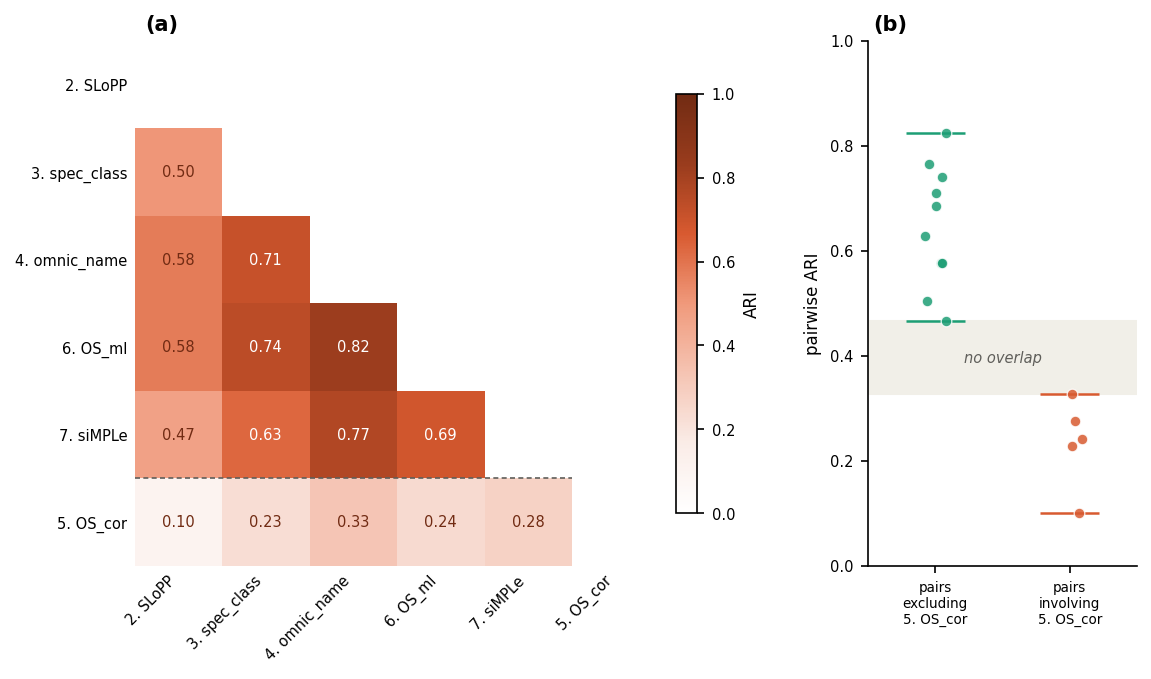

Fig 3 saved. involving range 0.10-0.33, excluding range 0.47-0.82
Caption: N = 47 (reference-free layer); (a) lower triangle of the
symmetric ARI matrix, outlier last, dashed separator; (b) the same 15 pair
values grouped by outlier involvement - the shaded band is the empty gap.


In [ ]:
# === F1 (Python): Fig 3: ARI as (a) lower-triangle heatmap + (b) pair strip
# Part F, first cell; run after C1 and D1. Needs: ARI, M47, OUT_DIR.
#
# Design:
#   (a) lower triangle only (many_pairwise_correlations pattern) - the upper
#       triangle of a symmetric matrix is pure duplication; outlier kept last
#       with dashed separator, diagonal masked.
#   (b) all 15 pairwise ARI values as two strips: pairs involving the outlying
#       stream vs pairs excluding it. The non-overlap of the two ranges - the
#       sentence "the two ranges do not overlap" - is visible as an empty gap.
# No in-figure titles; the caption carries N and panel meanings.

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

plt.rcParams.update({'figure.dpi': 150, 'font.size': 9})
SAVE_DPI = 600

C_TEAL, C_CORAL, C_GREY = '#1D9E75', '#D85A30', '#5F5E5A'
CMAP_CORAL = LinearSegmentedColormap.from_list(
    'coral_ramp', ['#FFFFFF', '#FAECE7', '#F5C4B3', '#F0997B', '#D85A30',
                   '#993C1D', '#712B13'])
CMAP_CORAL.set_bad('#FFFFFF')

try:
    OUTLIER = _out
except NameError:
    OUTLIER = next((c for c in ARI.index if 'OS_cor' in c), ARI.index[-1])
    print(f'! _out not in scope; falling back to name match -> {OUTLIER}')

order = [c for c in ARI.index if c != OUTLIER] + [OUTLIER]
A = ARI.loc[order, order].astype(float).values
n = len(order)
mask = np.triu(np.ones_like(A, dtype=bool))          # hide diagonal + upper
Am = np.where(mask, np.nan, A)

fig, (ax, axs) = plt.subplots(
    1, 2, figsize=(8.6, 4.6), gridspec_kw={'width_ratios': [3.1, 1.0]})

# ── (a) lower-triangle heatmap ───────────────────────────────────────────────
im = ax.imshow(np.ma.masked_invalid(Am), vmin=0, vmax=1, cmap=CMAP_CORAL,
               interpolation='nearest')
ax.set_xticks(range(n)); ax.set_xticklabels(order, rotation=45,
                                            ha='right', fontsize=7)
ax.set_yticks(range(n)); ax.set_yticklabels(order, fontsize=7)
k = n - 1
ax.plot([-.5, k - .5], [k - .5, k - .5], color=C_GREY, lw=.8, ls=(0, (3, 2)))
for i in range(n):
    for j in range(n):
        if not mask[i, j]:
            ax.text(j, i, f"{A[i, j]:.2f}", ha='center', va='center', fontsize=7,
                    color='white' if A[i, j] > .58 else '#712B13')
for side in ['top', 'right', 'left', 'bottom']:
    ax.spines[side].set_visible(False)
ax.tick_params(length=0)
cb = fig.colorbar(im, ax=ax, shrink=.8, pad=.02)
cb.set_label('ARI', fontsize=8); cb.ax.tick_params(labelsize=7)
ax.text(.02, 1.02, '(a)', transform=ax.transAxes, fontsize=10, fontweight='bold')

# ── (b) the 15 pair values, split by outlier involvement ─────────────────────
iu = np.triu_indices(n, 1)
vals  = A[iu]
inout = np.array([(order[i] == OUTLIER) or (order[j] == OUTLIER)
                  for i, j in zip(*iu)])
rng = np.random.default_rng(20260805)
for pos, sel, col, lab in [(0, ~inout, C_TEAL,  'excluding'),
                           (1,  inout, C_CORAL, 'involving')]:
    v = vals[sel]
    axs.scatter(pos + rng.uniform(-.10, .10, len(v)), v, s=26, alpha=.85,
                color=col, edgecolors='white', linewidths=.6, zorder=3)
    axs.hlines([v.min(), v.max()], pos - .22, pos + .22, color=col, lw=1.2)
gap_lo, gap_hi = vals[inout].max(), vals[~inout].min()
axs.axhspan(gap_lo, gap_hi, color='#F1EFE8', zorder=1)
axs.text(.5, (gap_lo + gap_hi) / 2, 'no overlap', ha='center', va='center',
         fontsize=7, color=C_GREY, style='italic')
axs.set_xlim(-.5, 1.5); axs.set_ylim(0, 1)
axs.set_xticks([0, 1])
axs.set_xticklabels([f'pairs\nexcluding\n{OUTLIER}', f'pairs\ninvolving\n{OUTLIER}'],
                    fontsize=6.5)
axs.tick_params(axis='y', labelsize=7)
axs.set_ylabel('pairwise ARI', fontsize=8)
for side in ['top', 'right']:
    axs.spines[side].set_visible(False)
axs.text(.02, 1.02, '(b)', transform=axs.transAxes, fontsize=10, fontweight='bold')

fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, 'Fig3_ari_matrix.png'),
            dpi=SAVE_DPI, bbox_inches='tight')
fig.savefig(os.path.join(OUT_DIR, 'Fig3_ari_matrix.pdf'), bbox_inches='tight')
plt.show()

print(f'Fig 3 saved. involving range {vals[inout].min():.2f}-{vals[inout].max():.2f}, '
      f'excluding range {vals[~inout].min():.2f}-{vals[~inout].max():.2f}')
print(f'Caption: N = {len(M47)} (reference-free layer); (a) lower triangle of the')
print('symmetric ARI matrix, outlier last, dashed separator; (b) the same 15 pair')
print('values grouped by outlier involvement - the shaded band is the empty gap.')

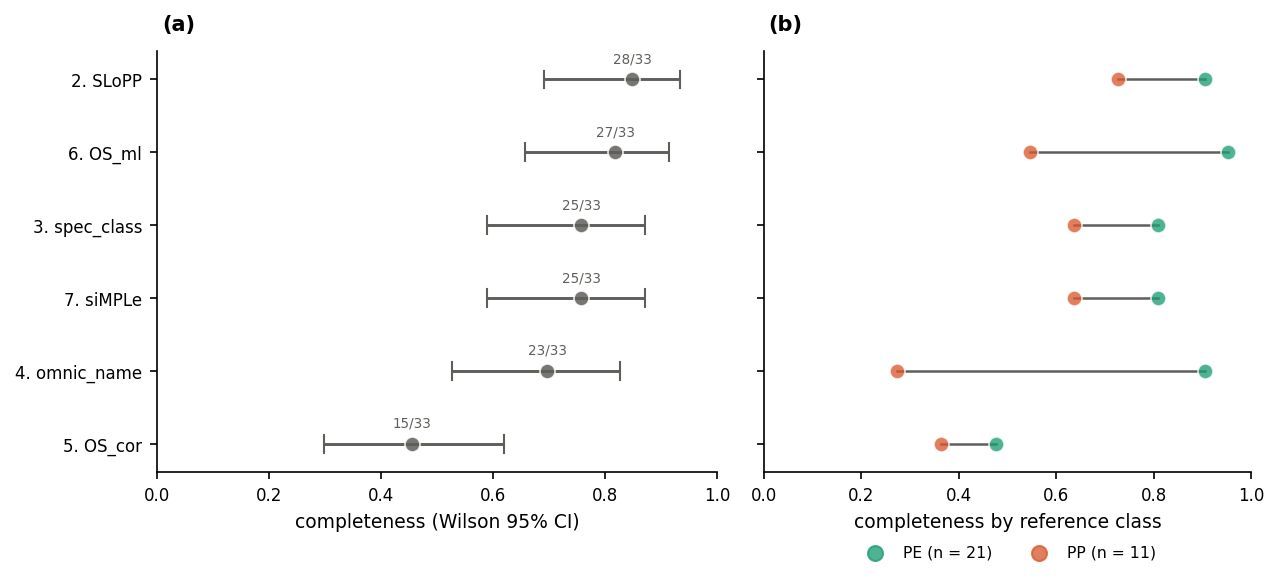

Fig 4 final saved. Cross-check against D.4:
  2. SLoPP         28/33 = 0.848 [0.691, 0.933]
  6. OS_ml         27/33 = 0.818 [0.656, 0.914]
  3. spec_class    25/33 = 0.758 [0.590, 0.872]
  7. siMPLe        25/33 = 0.758 [0.590, 0.872]
  4. omnic_name    23/33 = 0.697 [0.527, 0.826]
  5. OS_cor        15/33 = 0.455 [0.298, 0.620]
Panel (b) values must match the D.3 stratified table; PS excluded by design.


In [ ]:
# === F1a (Python): Fig 4: completeness with CIs + PE/PP dumbbell ============
# Part F, after the Fig 3 cell; run after C1 and D1.
# Needs: SCORED, IND, ACTIVE, REF_COL, OUT_DIR.
#
#   (a) dots are neutral grey (#5F5E5A, alpha .85, white edge) - the panel
#       shows the UNstratified whole, which panel (b) then decomposes into
#       PE (teal) / PP (coral); the colour narrative mirrors that logic and
#       avoids reading (a)'s dots as a class.
#   (b) legend moved below the axis (outside), clear of the OS_cor row.
# Streams sorted by completeness (desc) in both panels; k/33 kept above each
# CI dot (caption: "the fraction above each point gives agreeing particles
# over the 33 scored").

import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({'figure.dpi': 150, 'font.size': 9})
SAVE_DPI = 600
C_TEAL, C_CORAL, C_GREY = '#1D9E75', '#D85A30', '#5F5E5A'

def wilson(k, n, z=1.959964):
    if n == 0: return (np.nan, np.nan, np.nan)
    p = k / n
    d = 1 + z*z/n
    c = (p + z*z/(2*n)) / d
    h = z*np.sqrt(p*(1-p)/n + z*z/(4*n*n)) / d
    return p, c-h, c+h

ref = SCORED[REF_COL].astype(str)
rows = []
for s in ACTIVE:
    ind = IND[s['key']].loc[SCORED.index].astype(float)
    k, n = int(ind.sum()), int(ind.notna().sum())
    p, lo, hi = wilson(k, n)
    pe = ind[ref.values == 'polyolefin_PE']
    pp = ind[ref.values == 'polyolefin_PP']
    rows.append(dict(name=f"{s['no']}. {s['name']}", p=p, lo=lo, hi=hi, k=k, n=n,
                     pe=pe.mean(), pe_n=int(pe.notna().sum()),
                     pp=pp.mean(), pp_n=int(pp.notna().sum())))
rows.sort(key=lambda r: r['p'], reverse=True)
ypos = np.arange(len(rows))[::-1]

fig, (ax, axd) = plt.subplots(1, 2, figsize=(8.6, 4.0), sharey=True,
                              gridspec_kw={'width_ratios': [1.15, 1.0]})

# ── (a) completeness with Wilson 95% CI (neutral grey = unstratified whole) ──
for yv, r in zip(ypos, rows):
    ax.hlines(yv, r['lo'], r['hi'], color=C_GREY, lw=1.4, zorder=2)
    ax.plot([r['lo'], r['lo']], [yv-.12, yv+.12], color=C_GREY, lw=1.0)
    ax.plot([r['hi'], r['hi']], [yv-.12, yv+.12], color=C_GREY, lw=1.0)
    ax.scatter(r['p'], yv, s=52, color=C_GREY, alpha=.85,
               edgecolors='white', linewidths=.8, zorder=3)
    ax.annotate(f"{r['k']}/{r['n']}", (r['p'], yv), xytext=(0, 8),
                textcoords='offset points', ha='center', fontsize=6.5,
                color=C_GREY)
ax.set_yticks(ypos); ax.set_yticklabels([r['name'] for r in rows], fontsize=8)
ax.set_xlim(0, 1); ax.set_xlabel('completeness (Wilson 95% CI)', fontsize=9)
ax.tick_params(labelsize=8)
for side in ['top', 'right']:
    ax.spines[side].set_visible(False)
ax.text(.01, 1.05, '(a)', transform=ax.transAxes, fontsize=10, fontweight='bold')

# ── (b) PE vs PP dumbbell (teal / coral), legend outside below ───────────────
for yv, r in zip(ypos, rows):
    axd.plot([r['pp'], r['pe']], [yv, yv], color=C_GREY, lw=1.2, zorder=2)
    axd.scatter(r['pe'], yv, s=52, color=C_TEAL, alpha=.78, zorder=3,
                edgecolors='white', linewidths=.8)
    axd.scatter(r['pp'], yv, s=52, color=C_CORAL, alpha=.78, zorder=3,
                edgecolors='white', linewidths=.8)
axd.scatter([], [], s=52, color=C_TEAL,  alpha=.78, label=f"PE (n = {rows[0]['pe_n']})")
axd.scatter([], [], s=52, color=C_CORAL, alpha=.78, label=f"PP (n = {rows[0]['pp_n']})")
axd.legend(fontsize=7.5, frameon=False, ncol=2,
           loc='upper center', bbox_to_anchor=(.5, -.14))
axd.set_xlim(0, 1)
axd.set_xlabel('completeness by reference class', fontsize=9)
axd.tick_params(labelsize=8)
for side in ['top', 'right']:
    axd.spines[side].set_visible(False)
axd.text(.01, 1.05, '(b)', transform=axd.transAxes, fontsize=10, fontweight='bold')

fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, 'Fig4_completeness_ci_pepp.png'),
            dpi=SAVE_DPI, bbox_inches='tight')
fig.savefig(os.path.join(OUT_DIR, 'Fig4_completeness_ci_pepp.pdf'),
            bbox_inches='tight')
plt.show()

chk = {r['name']: f"{r['k']}/{r['n']} = {r['p']:.3f} [{r['lo']:.3f}, {r['hi']:.3f}]"
       for r in rows}
print('Fig 4 final saved. Cross-check against D.4:')
for k_, v_ in chk.items():
    print(f'  {k_:<16} {v_}')
print('Panel (b) values must match the D.3 stratified table; PS excluded by design.')

column resolution:
  1. Raman ref       -> raman_gt
  2. SLoPP           -> B_label
  3. spec_class      -> spec_class
  4. omnic_name      -> omnic_name
  5. OS_cor          -> openspecy_name
  6. OS_ml           -> ml_name
  7. siMPLe          -> simple_name
raw-vs-norm check (variants that normalisation had been merging):
  none - raw display is purely cosmetic; node counts unchanged


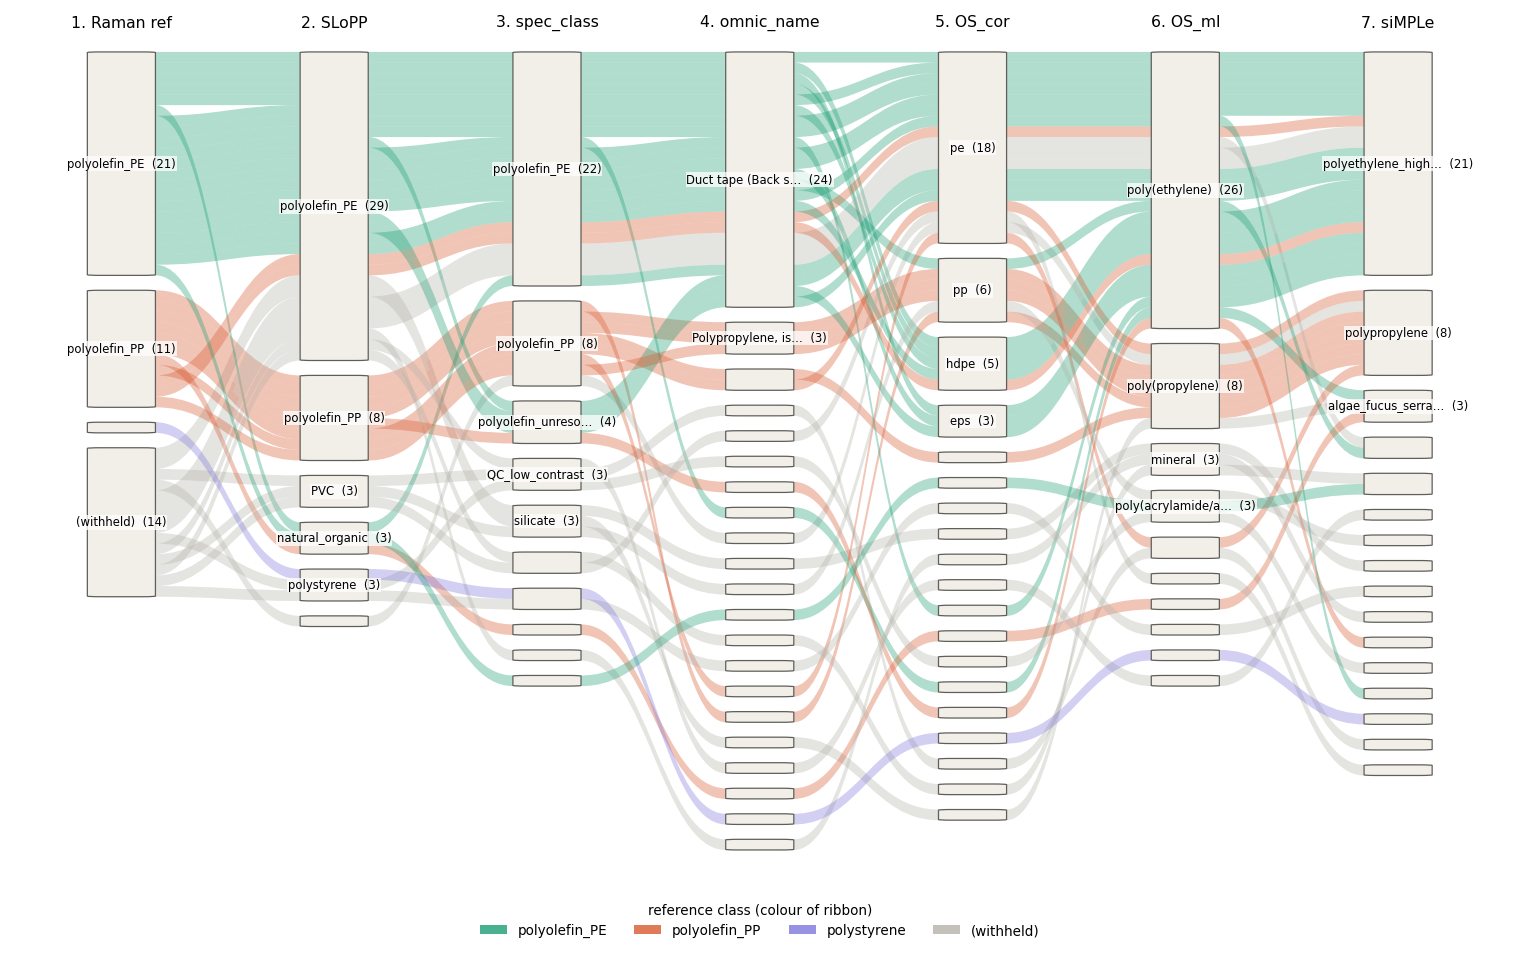

Fig 2 saved (raw labels; no in-figure title).
Check the column-resolution list above: every stream must map to a raw column.
If the raw-vs-norm check listed variants above, node counts exceed the scoring
group counts; a caption note that entries differing only in case or spacing are
drawn as separate nodes would cover this.


In [ ]:
# === F1b (Python): Figure 2: verbatim-label alluvial, RAW labels ============
# Part F, immediately after F1, before F2. Run after C1 and D1.
# Needs: M47, ACTIVE, REF_COL, OUT_DIR (all defined upstream).
#
#   - Raw columns are resolved through an EXPLICIT mapping (RAW_COL); if a mapping or
#     column is missing the cell STOPS with a clear error rather than quietly falling
#     back to the '_norm' columns.
#   - Nodes show each stream's label exactly as in the master table and Table 3
#     (polyolefin_PE, Duct tape (Back side), ...). '_norm' remains the basis of D1
#     scoring; this figure only displays raw strings.
#   - The guard prints any raw variants that '_norm' merges; if listed, state in the
#     caption that node counts and scoring group counts differ.
#   - No in-figure title (caption carries it); saved as Fig2_*.

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.path import Path as MplPath
import matplotlib.patches as mpatches

LABEL_MIN   = 3
TRUNC       = 18
GAP         = 1.4
BLOCK_W     = 0.16
RIBBON_A    = 0.35

# ── raw-column resolution (explicit; fails loudly) ───────────────────────────
# stream key/name fragment -> raw column in M47 (from the Stream coverage table)
RAW_COL = {
    'SLoPP':      'B_label',
    'spec_class': 'spec_class',
    'omnic':      'omnic_name',
    'OS_cor':     'openspecy_name',
    'OS_ml':      'ml_name',
    'siMPLe':     'simple_name',
}

def raw_col(s):
    ident = f"{s.get('key','')}|{s.get('name','')}"
    for frag, colname in RAW_COL.items():
        if frag.lower() in ident.lower():
            if colname not in M47.columns:
                raise KeyError(
                    f"raw column '{colname}' for stream {s.get('name')} not in M47. "
                    f"Available non-norm columns: "
                    f"{[c for c in M47.columns if not str(c).endswith('_norm')]}")
            return colname
    raise KeyError(
        f"no RAW_COL mapping matches stream key/name '{ident}'. "
        f"Edit the RAW_COL dict at the top of this cell.")

COLS     = [REF_COL] + [raw_col(s) for s in ACTIVE]
COLNAMES = ['1. Raman ref'] + [f"{s['no']}. {s['name']}" for s in ACTIVE]
print('column resolution:')
for nm, c in zip(COLNAMES, COLS):
    print(f'  {nm:<18} -> {c}')
assert not any(str(c).endswith('_norm') for c in COLS[1:]), \
    'a stream resolved to a _norm column; fix RAW_COL before drawing'

# ── guard: raw vs normalised grouping ────────────────────────────────────────
print('raw-vs-norm check (variants that normalisation had been merging):')
_any = False
for s in ACTIVE:
    rc, nc = raw_col(s), s['key'] + '_norm'
    if nc not in M47.columns:
        continue
    raw_lab = M47[rc].dropna().astype(str)
    norm_of = raw_lab.str.strip().str.lower()   # approximate the _norm rule;
                                                # align with C1 if it does more
    for nval, grp in raw_lab.groupby(norm_of):
        variants = sorted(grp.unique())
        if len(variants) > 1:
            _any = True
            print(f"  [{s['name']}] {variants}  -> were ONE node, now {len(variants)}")
if not _any:
    print('  none - raw display is purely cosmetic; node counts unchanged')

# ── data frame for drawing ───────────────────────────────────────────────────
W = M47.copy()
W['_ref_class'] = np.where(W['withheld'], '(withheld)', W[REF_COL].astype(str))
W = W.reset_index(drop=True)
DRAW = {}                       # column position k -> Series of node strings
DRAW[0] = W['_ref_class']
for k, c in enumerate(COLS[1:], start=1):
    DRAW[k] = W[c].fillna('(no output)').astype(str)
N = len(W)

REF_COLOR = {'polyolefin_PE': '#1D9E75', 'polyolefin_PP': '#D85A30',
             'polystyrene':   '#7F77DD', '(withheld)':    '#B4B2A9'}
REF_ORDER = {'polyolefin_PE': 0, 'polyolefin_PP': 1, 'polystyrene': 2, '(withheld)': 3}
colour = W['_ref_class'].map(lambda r: REF_COLOR.get(r, '#888780')).tolist()

# ── vertical layout, column by column ────────────────────────────────────────
Y      = np.zeros((len(COLS), N))
BLOCKS = []
prev_y = None
for k in range(len(COLS)):
    ser = DRAW[k]
    if k == 0:
        order_key = W['_ref_class'].map(REF_ORDER).fillna(9)
        groups = sorted(ser.groupby(ser).groups.items(),
                        key=lambda kv: order_key.loc[list(kv[1])].min())
    else:
        groups = sorted(ser.groupby(ser).groups.items(),
                        key=lambda kv: (-len(kv[1]), str(kv[0])))
    cursor = 0.0
    for lab, idx in groups:
        idx = list(idx)
        if prev_y is not None:
            idx = sorted(idx, key=lambda i: prev_y[i])
        else:
            idx = sorted(idx, key=lambda i: REF_ORDER.get(W.loc[i, '_ref_class'], 9))
        top = cursor
        for i in idx:
            Y[k, i] = cursor
            cursor += 1.0
        BLOCKS.append((k, str(lab), top, cursor, len(idx)))
        cursor += GAP
    prev_y = Y[k]

H = Y.max() + 1 + GAP

# ── draw ─────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10.2, 6.4))
xs = np.arange(len(COLS), dtype=float)

def ribbon(x0, y0, x1, y1, col):
    xm0, xm1 = x0 + 0.45 * (x1 - x0), x0 + 0.55 * (x1 - x0)
    verts = [(x0, y0), (xm0, y0), (xm1, y1), (x1, y1),
             (x1, y1 + 1), (xm1, y1 + 1), (xm0, y0 + 1), (x0, y0 + 1), (x0, y0)]
    codes = [MplPath.MOVETO, MplPath.CURVE4, MplPath.CURVE4, MplPath.CURVE4,
             MplPath.LINETO, MplPath.CURVE4, MplPath.CURVE4, MplPath.CURVE4,
             MplPath.CLOSEPOLY]
    ax.add_patch(mpatches.PathPatch(MplPath(verts, codes), facecolor=col,
                                    edgecolor='none', alpha=RIBBON_A, zorder=1))

for k in range(len(COLS) - 1):
    for i in range(N):
        ribbon(xs[k] + BLOCK_W, Y[k, i], xs[k + 1] - BLOCK_W, Y[k + 1, i], colour[i])

for k, lab, top, bot, n in BLOCKS:
    ax.add_patch(mpatches.FancyBboxPatch(
        (xs[k] - BLOCK_W, top), 2 * BLOCK_W, bot - top,
        boxstyle='round,pad=0,rounding_size=0.06',
        facecolor='#F1EFE8', edgecolor='#5F5E5A', linewidth=0.6, zorder=3))
    if n >= LABEL_MIN:
        s = lab if len(lab) <= TRUNC else lab[:TRUNC - 1] + '…'
        ax.text(xs[k], (top + bot) / 2, f"{s}  ({n})", ha='center', va='center',
                fontsize=5.6, zorder=4,
                bbox=dict(facecolor='white', edgecolor='none', alpha=.75, pad=0.4))

for k, name in enumerate(COLNAMES):
    ax.text(xs[k], -GAP - 0.6, name, ha='center', va='bottom', fontsize=7.5,
            fontweight='medium')

handles = [mpatches.Patch(facecolor=v, alpha=.8, label=k) for k, v in REF_COLOR.items()]
ax.legend(handles=handles, loc='lower center', bbox_to_anchor=(0.5, -0.10),
          ncol=4, fontsize=6.5, frameon=False,
          title='reference class (colour of ribbon)', title_fontsize=6.5)

ax.set_xlim(-0.5, len(COLS) - 0.5)
ax.set_ylim(H, -GAP - 2.0)
ax.axis('off')
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, 'Fig2_alluvial_verbatim.png'),
            dpi=600, bbox_inches='tight')
fig.savefig(os.path.join(OUT_DIR, 'Fig2_alluvial_verbatim.pdf'), bbox_inches='tight')
plt.show()

print('Fig 2 saved (raw labels; no in-figure title).')
print('Check the column-resolution list above: every stream must map to a raw column.')
print('If the raw-vs-norm check listed variants above, node counts exceed the scoring')
print('group counts; a caption note that entries differing only in case or spacing are')
print('drawn as separate nodes would cover this.')

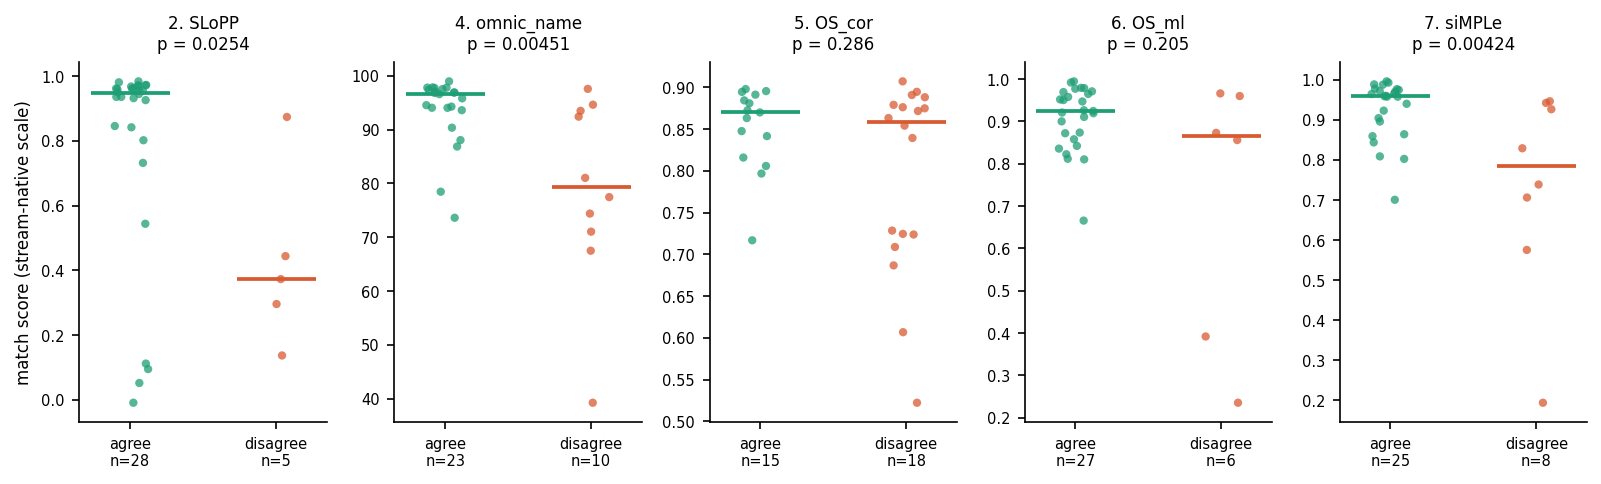

       stream           score_col  n_agree  n_disagree  median_agree  median_disagree  mannwhitney_p
     2. SLoPP                 B_r       28           5         0.948            0.373        0.02544
4. omnic_name                 hqi       23          10        96.590           79.245        0.00451
    5. OS_cor openspecy_match_val       15          18         0.870            0.859        0.28616
     6. OS_ml             ml_prob       27           6         0.925            0.865        0.20500
    7. siMPLe        simple_score       25           8         0.959            0.784        0.00424

Caption must state (body covers spec_class and the reference axis):
  - per-panel native scales; values not comparable across panels
  - median bars; Mann-Whitney p descriptive (disagree n = 5-18)

Check item for step 3: SLoPP agree group contains near-zero r points -
identify those particles in the D.5 source data before submission.


In [ ]:
# === F1c (Python): Fig 5: match score vs agreement, within each stream ======
# Part F, immediately after F1b, before F2. Run after C1 and D1.
# Needs: SCORED, IND, ACTIVE (D1), stats (setup), OUT_DIR.
#
# Figure form of D.5. One panel per scoring stream; within each panel, the
# stream's own score for particles that AGREE with the reference vs those that
# DISAGREE (completeness indicator from D.1). Everything stays within-stream:
# y axes are per-panel native scales (HQI 0-100, the rest 0-1) and no
# cross-stream comparison is drawn.
# Numbered Fig 5; no suptitle (caption carries N and the scale
# restriction); dpi 600. spec_class absence and the reference-axis exclusion
# are stated in the BODY (Section 3.6, paragraph 2), not in the caption.

import numpy as np
import matplotlib.pyplot as plt

rng    = np.random.default_rng(20260805)          # jitter only
panels = [s for s in ACTIVE if s.get('score') and s['score'] in SCORED.columns]

C_AGREE, C_DIS = '#1D9E75', '#D85A30'
SAVE_DPI = 600
fig, axes = plt.subplots(1, len(panels), figsize=(2.15 * len(panels), 3.3))
if len(panels) == 1:
    axes = [axes]

rows = []
for ax, s in zip(axes, panels):
    ind = IND[s['key']]
    a = SCORED.loc[ind == 1, s['score']].dropna().astype(float)   # agree
    b = SCORED.loc[ind == 0, s['score']].dropna().astype(float)   # disagree

    for pos, (v, col) in enumerate([(a, C_AGREE), (b, C_DIS)]):
        x = pos + rng.uniform(-0.13, 0.13, len(v))
        ax.scatter(x, v, s=16, alpha=0.75, color=col, edgecolors='none', zorder=2)
        if len(v):
            ax.hlines(v.median(), pos - 0.27, pos + 0.27, color=col, lw=1.8, zorder=3)

    if len(a) >= 3 and len(b) >= 3:
        p = stats.mannwhitneyu(a, b, alternative='two-sided').pvalue
        ptxt = f"p = {p:.3g}"
    else:
        p, ptxt = np.nan, 'n too small'
    ax.set_title(f"{s['no']}. {s['name']}\n{ptxt}", fontsize=8)
    ax.set_xticks([0, 1])
    ax.set_xticklabels([f"agree\nn={len(a)}", f"disagree\nn={len(b)}"], fontsize=7)
    ax.tick_params(axis='y', labelsize=7)
    for side in ['top', 'right']:
        ax.spines[side].set_visible(False)

    lo = min([v.min() for v in (a, b) if len(v)], default=0)
    hi = max([v.max() for v in (a, b) if len(v)], default=1)
    pad = 0.06 * (hi - lo if hi > lo else 1)
    ax.set_ylim(lo - pad, hi + pad)

    rows.append(dict(stream=f"{s['no']}. {s['name']}", score_col=s['score'],
                     n_agree=len(a), n_disagree=len(b),
                     median_agree=round(float(a.median()), 3) if len(a) else np.nan,
                     median_disagree=round(float(b.median()), 3) if len(b) else np.nan,
                     mannwhitney_p=round(float(p), 5) if p == p else np.nan))

axes[0].set_ylabel('match score (stream-native scale)', fontsize=8)
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, 'Fig5_score_vs_agreement.png'),
            dpi=SAVE_DPI, bbox_inches='tight')
fig.savefig(os.path.join(OUT_DIR, 'Fig5_score_vs_agreement.pdf'), bbox_inches='tight')
plt.show()

FIG5 = pd.DataFrame(rows)
FIG5.to_csv(os.path.join(OUT_DIR, 'Fig5_score_vs_agreement_summary.csv'), index=False)
print(FIG5.to_string(index=False))
print('\nCaption must state (body covers spec_class and the reference axis):')
print('  - per-panel native scales; values not comparable across panels')
print('  - median bars; Mann-Whitney p descriptive (disagree n = 5-18)')
print('\nCheck item for step 3: SLoPP agree group contains near-zero r points -')
print('identify those particles in the D.5 source data before submission.')

In [ ]:
# === F2 (Python): stream dictionary for the supplementary material ==========
# Tables and figures identify streams by a short label; the distributed CSV files keep the
# raw column names. This dictionary is the bridge, and belongs in the supplementary material
# so that a reader can open code3_master_n47.csv and connect it to the tables built from it.
DICT = pd.DataFrame([dict(label=DISPLAY[s['key']], csv_column=s['key'], modality=s['modality'],
                          score_column=s['score'] or '', library=s.get('library', ''),
                          active=s['key'] in [a['key'] for a in ACTIVE])
                     for s in STREAMS])
DICT = pd.concat([pd.DataFrame([dict(label=DISPLAY[REF_COL], csv_column=REF_COL,
                                     modality='Raman', score_column='raman_conf',
                                     library='reference axis: diagnostic band library, ranking '
                                             'rule and evidence floor; a reproducible rule, not '
                                             'a verified ground truth',
                                     active=True)]), DICT], ignore_index=True)
display(DICT)

DICT_CSV = os.path.join(OUT_DIR, 'SI_stream_dictionary.csv')
DICT.to_csv(DICT_CSV, index=False, encoding='utf-8-sig')
print(f"wrote {DICT_CSV}")
print("  Label '2. SLoPP' covers both the SLoPP and SLoPP-E libraries (a point for the table")
print("  footnotes). Label '7. siMPLe' is the reference library, not the siMPLe software.")


,label,csv_column,modality,score_column,library,active
0,1. Raman ref,raman_gt,Raman,raman_conf,reference axis: diagnostic ban...,True
1,2. SLoPP,B_label,Raman,B_r,SLoPP and SLoPP-E Raman librar...,True
2,3. spec_class,spec_class,FT-IR,,"in-house rule, functional-grou...",True
3,4. omnic_name,omnic_name,FT-IR,hqi,OMNIC commercial libraries (Th...,True
4,5. OS_cor,openspecy_name,FT-IR,openspecy_match_val,Open Specy derivative referenc...,True
5,6. OS_ml,ml_name,FT-IR,ml_prob,Open Specy model_derivative mu...,True
6,7. siMPLe,simple_name,FT-IR,simple_score,siMPLe ATR single-spectra refe...,True


wrote /content/code3_out/SI_stream_dictionary.csv
  Label '2. SLoPP' covers both the SLoPP and SLoPP-E libraries (a point for the table
  footnotes). Label '7. siMPLe' is the reference library, not the siMPLe software.


In [ ]:
# === F3 (Python): reporting values, manifest, retrieval =====================
# Values are collected into V, printed as reporting notes, stored in the manifest and
# recomputable from code3_master_n47.csv. No sentence is generated here.

def _num(v):
    """Integral values print as 4, not 4.0."""
    try:
        f = float(v)
        return int(f) if f == int(f) else round(f, 3)
    except (TypeError, ValueError):
        return v



# ---- values available to the templates --------------------------------------
V = {}
V['n_streams']    = len(ACTIVE) + 1
V['n_compared']   = len(ACTIVE)
V['n_particles']  = len(M47)
V['n_scored']     = len(SCORED)
V['n_withheld']   = int(M47.withheld.sum())
try:
    V['Q']    = f"{RESULT_Q['Q']:.1f}"
    V['Q_df'] = RESULT_Q['df']
    V['Q_p']  = '< 0.0001' if (not pd.isna(RESULT_Q['p']) and RESULT_Q['p'] < 1e-4) else f"{RESULT_Q['p']:.3g}"
except (NameError, TypeError):
    pass
try:
    if _sep:
        V['outlier']      = _out.split('.', 1)[-1].strip()
        V['out_lo']       = f"{min(_with):.2f}"
        V['out_hi']       = f"{max(_with):.2f}"
        V['others_lo']    = f"{min(_wout):.2f}"
        V['others_hi']    = f"{max(_wout):.2f}"
except NameError:
    pass
try:
    if dropped:
        V['simple_refs']    = STREAM7_VOCAB['n_refs']
        V['simple_names']   = STREAM7_VOCAB['n_names']
        V['simple_dropped'] = len(dropped)
except NameError:
    pass
try:                                    # from the granularity sensitivity cell (E2)
    _e, _c = GRAN_ROWS[0], GRAN_ROWS[1]
    V['gran_entry_labels'] = _num(_e['n_labels'])
    V['gran_class_labels'] = _num(_c['n_labels'])
    V['gran_entry_comp']   = f"{_e['completeness']:.2f}"
    V['gran_class_comp']   = f"{_c['completeness']:.2f}"
    _bv = [v for v in GRAN_ARI_CLASS.values() if not pd.isna(v)]
    V['gran_class_lo'], V['gran_class_hi'] = f"{min(_bv):.2f}", f"{max(_bv):.2f}"
except (NameError, IndexError, KeyError, TypeError):
    pass

# ---- reporting values -------------------------------------------------------
# Values only; how they appear in the article is the authors' decision. Everything below is also stored in
# code3_manifest.json (reporting_values) and recomputable from code3_master_n47.csv.
print("=" * 78); print("[reporting note] values from this run")
for k, v in V.items():
    print(f"  {k:<18} = {v}")
print("-" * 78)
print("[reporting note] per-stream summary (from D.1; purity over labels with n>=2)")
for s in ACTIVE:
    r = SUMMARY.loc[f"{s['no']}. {s['name']}"]
    print(f"  {s['name']:<12} labels {_num(r['n_labels']):>3} over {_num(r['n_scored'])} particles | "
          f"purity_ge2 {_num(r['purity_ge2'])} ({_num(r['n_labels_ge2'])} labels, n={_num(r['n_scored_ge2'])}) | "
          f"completeness {_num(r['completeness'])}")
print("-" * 78)
print("Terminology reminder: 'agreement with the Raman Code1 Reference', never 'accuracy'")
print("or 'ground truth'; the reference is a rule output, not a verified identity.")

with open(os.path.join(OUT_DIR, 'code3_manifest.json'), 'w', encoding='utf-8') as fh:
    json.dump(dict(code3_version=CODE3_VERSION, upstream=UPSTREAM,
                   n_catalogue=len(master), n_raman=len(M47), n_scored=len(SCORED),
                   streams_active=[s['no'] for s in ACTIVE], join_key=JOIN_KEY,
                   thresholds=dict(openspecy=OS_THRESHOLD, classifier=ML_THRESHOLD),
                   reporting_values=V, frozen_decisions=FROZEN_DECISIONS),
              fh, ensure_ascii=False, indent=2)

_dst = os.path.join(PROJECT, 'code3_out'); os.makedirs(_dst, exist_ok=True)
_n = sum(bool(shutil.copy(os.path.join(OUT_DIR, f), _dst))
         for f in sorted(os.listdir(OUT_DIR)) if os.path.isfile(os.path.join(OUT_DIR, f)))
print(f"\n{_n} file(s) copied to {_dst}")
for f, role in [('code3_master_n47.csv', 'primary result / supplementary data'),
                ('code3_master_all230.csv', 'all FT-IR spectra'),
                ('Fig2_alluvial_verbatim.png', 'main figure 2'),
                ('Fig3_ari_matrix.png', 'main figure 3'),
                ('Fig4_completeness_ci_pepp.png', 'main figure 4'),
                ('Fig5_score_vs_agreement.png', 'main figure 5'),
                ('SI_pairwise_mcnemar_bh.csv', 'supplementary'),
                ('SI_ari_by_stratum.csv', 'supplementary'),
                ('SI_granularity_stream5.csv', 'supplementary'),
                ('SI_granularity_ari.csv', 'supplementary'),
                ('SI_stream_dictionary.csv', 'supplementary: label <-> column'),
                ('code3_manifest.json', 'run record')]:
    print(f"  {'ok ' if os.path.exists(os.path.join(_dst, f)) else '-- '}{f:<32}{role}")
print("\n  code2_out/ and raman_manual_out/ are never written to.")


[reporting note] values from this run
  n_streams          = 7
  n_compared         = 6
  n_particles        = 47
  n_scored           = 33
  n_withheld         = 14
  Q                  = 28.4
  Q_df               = 5
  Q_p                = < 0.0001
  outlier            = OS_cor
  out_lo             = 0.10
  out_hi             = 0.33
  others_lo          = 0.47
  others_hi          = 0.82
  simple_refs        = 322
  simple_names       = 219
  simple_dropped     = 3
  gran_entry_labels  = 11
  gran_class_labels  = 5
  gran_entry_comp    = 0.46
  gran_class_comp    = 0.67
  gran_class_lo      = 0.24
  gran_class_hi      = 0.44
------------------------------------------------------------------------------
[reporting note] per-stream summary (from D.1; purity over labels with n>=2)
  SLoPP        labels   4 over 33 particles | purity_ge2 0.906 (3 labels, n=32) | completeness 0.848
  spec_class   labels   6 over 33 particles | purity_ge2 0.9 (3 labels, n=30) | completeness 0.758
  omnic_n

In [ ]:
# === Session report (for Methods): Python side ===
import sys, platform, datetime, rpy2
import numpy, pandas, scipy, matplotlib
print("run date  :", datetime.datetime.now().strftime("%Y-%m-%d %H:%M"))
print("Python    :", sys.version.split()[0], "|", platform.platform())
for m in (numpy, pandas, scipy, matplotlib):
    print(f"{m.__name__:<10}: {m.__version__}")
print("rpy2      :", rpy2.__version__)

run date  : 2026-08-28 05:17
Python    : 3.13.15 | Linux-6.6.122+-x86_64-with-glibc2.35
numpy     : 2.1.3
pandas    : 2.2.3
scipy     : 1.16.3
matplotlib: 3.10.0
rpy2      : 3.5.17


In [ ]:
%%R
# === Session report: R side ===
cat(R.version.string, "\n")
cat("OpenSpecy", as.character(packageVersion("OpenSpecy")), "\n")

R version 4.6.1 (2026-06-24) 
OpenSpecy 1.5.3 
